# Advanced Process Mining Project – Group 1

## Setup

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import os, time, re
import multiprocessing, ctypes

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.colors import to_rgba
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Rectangle

from IPython.display import Image, display
from collections import Counter, defaultdict, deque
# from datetime import datetime, timedelta, time

import pm4py
from pm4py.visualization.dfg import visualizer as dfg_visualizer

# Import custom functions for the calculations with timeout
from timeout_workers import _fitness_worker, _precision_worker, _simplicity_worker

# Supress warnings
import warnings
warnings.filterwarnings('ignore') 

# Create directory for the images
os.makedirs("images", exist_ok=True)

In [2]:
# Verify the required versions (assignment requires Python 3.14.4 and PM4Py 2.7.22.2)
import sys, pm4py
print(f"Python: {sys.version.split()[0]}")
print(f"PM4Py:  {pm4py.__version__}")

Python: 3.13.5
PM4Py:  2.7.19.8


In [3]:
# Load the event logs
all_log = pm4py.read_xes('Event Logs/all.xes')
accepted_loans = pm4py.read_xes('Event Logs/accepted-loans.xes')
rejected_loans = pm4py.read_xes('Event Logs/rejected-loans.xes')
lcs_rejected_customers = pm4py.read_xes('Event Logs/lcs-rejected-customers.xes')
mid_rejected_customers = pm4py.read_xes('Event Logs/mid-rejected-customers.xes')
mla_rejected_customers = pm4py.read_xes('Event Logs/mla-rejected-customers.xes')

parsing log, completed traces ::   0%|          | 0/1820 [00:00<?, ?it/s]

parsing log, completed traces ::   0%|          | 0/1499 [00:00<?, ?it/s]

parsing log, completed traces ::   0%|          | 0/321 [00:00<?, ?it/s]

parsing log, completed traces ::   0%|          | 0/139 [00:00<?, ?it/s]

parsing log, completed traces ::   0%|          | 0/8 [00:00<?, ?it/s]

parsing log, completed traces ::   0%|          | 0/392 [00:00<?, ?it/s]

## <b>Question 1</b>: Initial Overview
At the beginning of a process mining analysis, it is advisable to obtain an initial overview of the event data.

In [4]:
print(f'Shape: {all_log.shape}')
all_log.head(5)

Shape: (47553, 27)


,concept:name,time:timestamp,org:resource,lifecycle:transition,case:concept:name,case:customer_id,case:customer_name,case:customer_ssid,case:loan_amount,case:case_creation_no,...,loan_decision,loan_decision_extra,interest,loan_term_years,recipient,transfer_amount,repayments,installment_target,repaid_amount,cumulatively_repaid
0,Application Registered,2021-01-03 09:04:01+00:00,System Resource,complete,470-16,470,Customer 470,6c710e01-8262-41dd-8476-688b1513d23c,500.0,16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Retrieve Identity Document,2021-01-03 09:04:02+00:00,System Resource,complete,470-16,470,Customer 470,6c710e01-8262-41dd-8476-688b1513d23c,500.0,16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Retrieve Internal Log Data,2021-01-03 10:12:01+00:00,Risk Assessment System,complete,470-16,470,Customer 470,6c710e01-8262-41dd-8476-688b1513d23c,500.0,16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Verify ID Automatically,2021-01-03 10:17:02+00:00,System Resource,complete,470-16,470,Customer 470,6c710e01-8262-41dd-8476-688b1513d23c,500.0,16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Confirmed Identity,2021-01-03 10:17:03+00:00,System Resource,complete,470-16,470,Customer 470,6c710e01-8262-41dd-8476-688b1513d23c,500.0,16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### <b>1a.</b> How many cases, events, and unique activities does the event log contain?

Additionally, what is the timeframe covered by the log (i.e., the duration between the
earliest and latest recorded event)?

In [5]:
# Counts
num_cases = all_log['case:concept:name'].nunique()
num_events = len(all_log)
num_activities = all_log['concept:name'].nunique()

# Timeframe 
timestamps = pd.to_datetime(all_log['time:timestamp'], utc=True)    # Convert everythingto UTC to avoid timezone issues
earliest = timestamps.min()
latest = timestamps.max()
timeframe = latest - earliest          

# Print results
print('=' * 55)
print('  EVENT LOG – BASIC STATISTICS')
print('=' * 55)
print(f'  Number of cases             : {num_cases}')
print(f'  Number of events            : {num_events}')
print(f'  Number of unique activities : {num_activities}')
print(f'  Earliest event              : {earliest}')
print(f'  Latest event                : {latest}')
print(f'  Log timeframe               : {timeframe}')
print('=' * 55)

  EVENT LOG – BASIC STATISTICS
  Number of cases             : 1820
  Number of events            : 47553
  Number of unique activities : 26
  Earliest event              : 2021-01-01 00:00:01+00:00
  Latest event                : 2023-09-13 09:00:03+00:00
  Log timeframe               : 985 days 09:00:02


The log contains 1 820 cases, 47 553 events, and 26 unique activities. It spans the period 2021-01-01 to 2023-09-13, covering 985 days (≈2 years 8 months).

In [6]:
print('Unique activities:')
for i, act in enumerate(sorted(all_log['concept:name'].unique()), 1):
    print(f'  {i}. {act}')

Unique activities:
  1. Accelerate Loan (Force Default)
  2. Accept Terms
  3. Application Registered
  4. Confirmed Identity
  5. Create Assessment Report
  6. Decide Loan Application
  7. Formally Initiate Debt Recovery
  8. Installment Received
  9. Loan Default Notice Received
  10. Query Central Bank System
  11. Query Credit Bureau
  12. Received Terms Acceptance
  13. Reject Application
  14. Repayment Completed
  15. Request to Defer Payment Received
  16. Retrieve Customer Global Risk Score
  17. Retrieve Financial Status
  18. Retrieve Identity Document
  19. Retrieve Internal Log Data
  20. Send Acceptance Confirmation
  21. Send Rejection Notification
  22. Send to Collections
  23. Start Repayments
  24. Transfer Funds
  25. Verify ID Automatically
  26. Verify ID Manually


### <b>1b.</b> Variants and Events per Case
How many variants are present in the log?
What is the average number of events per case?


In [7]:
# Variants
variants_dict = pm4py.get_variants(all_log)
num_variants = len(variants_dict)

# Average events per case
events_per_case = all_log.groupby('case:concept:name').size()

# Print results
print('=' * 40)
print('  VARIANTS & TRACE LENGTH')
print('=' * 40)
print(f'  Number of variants      : {num_variants}')
print(f'  Average events per case : {events_per_case.mean():0.2f}')
print(f'  Min events in a case    : {events_per_case.min()}')
print(f'  Max events in a case    : {events_per_case.max()}')
print('=' * 40)

  VARIANTS & TRACE LENGTH
  Number of variants      : 678
  Average events per case : 26.13
  Min events in a case    : 11
  Max events in a case    : 44


### <b>1c.</b> Which event attributes and case attributes are included in the log? 

Relate each event attribute to the corresponding activity or activities.

In [8]:
# Separate case columns
all_cols = all_log.columns.tolist()
case_cols = [c for c in all_cols if c.startswith('case:')]

print('CASE ATTRIBUTES')
print('-' * 65)
for col in case_cols:
    n_unique = all_log[col].nunique()
    sample = all_log[col].dropna().iloc[0] if all_log[col].notna().any() else 'N/A'
    print(f'  {col:<25}  unique: {n_unique:<6}  sample: {sample}')

CASE ATTRIBUTES
-----------------------------------------------------------------
  case:concept:name          unique: 1820    sample: 470-16
  case:customer_id           unique: 877     sample: 470
  case:customer_name         unique: 877     sample: Customer 470
  case:customer_ssid         unique: 877     sample: 6c710e01-8262-41dd-8476-688b1513d23c
  case:loan_amount           unique: 5       sample: 500.0
  case:case_creation_no      unique: 1820    sample: 16


In [9]:
# Separate event columns
event_cols = [c for c in all_cols
              if not c.startswith('case:')]

print('EVENT ATTRIBUTES')
print('-' * 75)
for col in event_cols:
    n_nn   = all_log[col].notna().sum()
    sample = all_log[col].dropna().iloc[0] if n_nn > 0 else 'N/A'
    print(f'  {col:<32}  non-null: {n_nn:<8}  sample: {sample}')

EVENT ATTRIBUTES
---------------------------------------------------------------------------
  concept:name                      non-null: 47553     sample: Application Registered
  time:timestamp                    non-null: 47553     sample: 2021-01-03 09:04:01+00:00
  org:resource                      non-null: 47553     sample: System Resource
  lifecycle:transition              non-null: 47553     sample: complete
  prior_defaults                    non-null: 3559      sample: []
  prior_applications                non-null: 3559      sample: []
  auto_id_verification_outcome      non-null: 1820      sample: valid
  risk_score                        non-null: 3559      sample: 0.56
  credit_score                      non-null: 3559      sample: 439.93
  code                              non-null: 323       sample: LCS
  manual_id_verification_outcome    non-null: 350       sample: invalid
  loan_decision                     non-null: 1732      sample: reject
  loan_decision_extra 

In [10]:
# Relate each event attribute to the activities where it appears

# Remove standard that appear in all events 
std_cols = {'concept:name', 'org:resource', 'time:timestamp', 'lifecycle:transition'}
event_cols = [c for c in event_cols if c not in std_cols]   

print('EVENT ATTRIBUTE  ->  ACTIVITY MAPPING')
print('=' * 70)
for col in event_cols:
    subset = all_log[all_log[col].notna()]
    if subset.empty:
        print(f'  Attribute : "{col}" - always null')
        continue
    activities = sorted(subset['concept:name'].unique())
    print(f'{col:<30} -> {activities}')

EVENT ATTRIBUTE  ->  ACTIVITY MAPPING
prior_defaults                 -> ['Create Assessment Report', 'Retrieve Internal Log Data']
prior_applications             -> ['Create Assessment Report', 'Retrieve Internal Log Data']
auto_id_verification_outcome   -> ['Verify ID Automatically']
risk_score                     -> ['Create Assessment Report', 'Retrieve Customer Global Risk Score']
credit_score                   -> ['Create Assessment Report', 'Retrieve Financial Status']
code                           -> ['Reject Application']
manual_id_verification_outcome -> ['Verify ID Manually']
loan_decision                  -> ['Decide Loan Application']
loan_decision_extra            -> ['Decide Loan Application']
interest                       -> ['Received Terms Acceptance']
loan_term_years                -> ['Received Terms Acceptance']
recipient                      -> ['Transfer Funds']
transfer_amount                -> ['Transfer Funds']
repayments                     -> ['Start Repaym

Standard XES attributes (`concept:name`, `org:resource`, `time:timestamp`, `lifecycle:transition`) are excluded from the mapping, because they appear in every activity.

### <b>1d.</b> Analyze the frequency distribution of variants.

Create a plot with variant frequency on
the y-axis and variants on the x-axis, sorted in descending order of frequency. What insights can you derive about
the process?

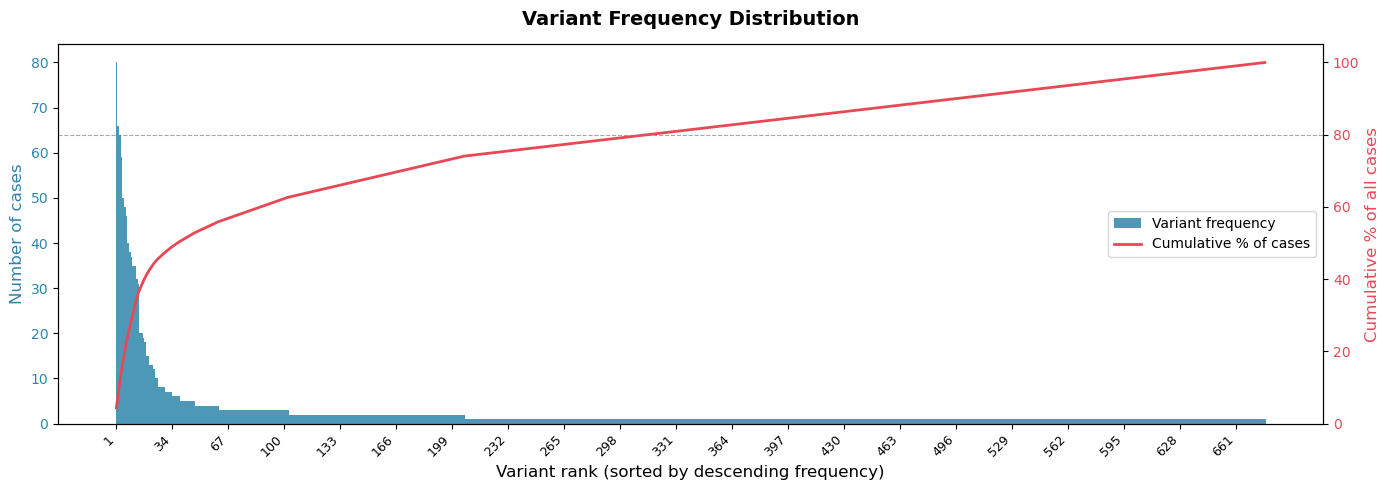

Total variants         : 678
Top-1 variant covers   : 80 (4.4%)
Top-5 variants cover   : 319 (17.5%)
Top-10 variants cover  : 528 (29.0%)
Singleton variants     : 472 (69.6%)
80% of cases covered by top-314 variant(s)
Remaining 364 variants cover the last 20% of cases


In [11]:
# Build sorted frequency series
variant_freq = pd.Series(
    {v: len(cases) if not isinstance(cases, int) else cases
     for v, cases in variants_dict.items()},
    name='frequency'
).sort_values(ascending=False)

ranks = list(range(1, len(variant_freq) + 1))
freqs = variant_freq.values
cum_pct = np.cumsum(freqs) / freqs.sum() * 100   # cumulative percentage

# Plot
fig, ax1 = plt.subplots(figsize=(14, 5))

# Bar chart of frequencies
ax1.bar(ranks, freqs, color='#2E86AB', alpha=0.85, width=1.0, label='Variant frequency')
ax1.set_xlabel('Variant rank (sorted by descending frequency)', fontsize=12)
ax1.set_ylabel('Number of cases', fontsize=12, color='#2E86AB')
ax1.tick_params(axis='y', labelcolor='#2E86AB')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Show x-ticks sparsely so labels do not overlap
tick_step = max(1, len(ranks) // 20)
ax1.set_xticks(ranks[::tick_step])
ax1.set_xticklabels(ranks[::tick_step], rotation=45, ha='right', fontsize=9)

# Cumulative line on secondary axis
ax2 = ax1.twinx()
ax2.plot(ranks, cum_pct, color='#E84855', linewidth=2, label='Cumulative % of cases')
ax2.axhline(80, color='grey', linestyle='--', linewidth=0.8, alpha=0.7)
ax2.set_ylabel('Cumulative % of all cases', fontsize=12, color='#E84855')
ax2.tick_params(axis='y', labelcolor='#E84855')
ax2.set_ylim(0, 105)

plt.title('Variant Frequency Distribution', fontsize=14, fontweight='bold', pad=14)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right', fontsize=10)
plt.tight_layout()
plt.show()

# Supporting numbers
idx80 = int(np.searchsorted(cum_pct, 80))
n_singleton = sum(f == 1 for f in freqs)
print(f'Total variants         : {len(freqs)}')
print(f"Top-1 variant covers   : {freqs[0]} ({100*freqs[0]/sum(freqs):.1f}%)")
print(f"Top-5 variants cover   : {sum(freqs[:5])} ({100*sum(freqs[:5])/sum(freqs):.1f}%)")
print(f"Top-10 variants cover  : {sum(freqs[:10])} ({100*sum(freqs[:10])/sum(freqs):.1f}%)")
print(f"Singleton variants     : {n_singleton} ({100*n_singleton/len(freqs):.1f}%)")
print(f'80% of cases covered by top-{idx80+1} variant(s)')
print(f'Remaining {len(ranks)-(idx80+1)} variants cover the last 20% of cases')

Only a few variants occur often, and most variants occur very rarely: the most frequent variant only covers 80 cases (≈4.4 % of all cases), the top-10 variants together cover only ≈29 % of the cases, and ≈70 % of all variants (472 of 678) occur in just one single case. There is no clear main path through the process, and we see a lot of different behavior. Process discovery algorithms will probably have a hard time with this.

### <b>1e.</b> Examine the distribution of case durations. 

Report the minimum, maximum, mean, median, and standard deviation of case duration.
What insights can you derive about the process? (approx. 3–4 sentences)

In [12]:
# Compute case durations
durations = (all_log.groupby("case:concept:name")["time:timestamp"]
                  .agg(lambda s: s.max() - s.min()))
secs = durations.dt.total_seconds()

# Descriptive statistics
stats = {
    'Minimum'         : durations.min(),
    'Maximum'         : durations.max(),
    'Mean'            : durations.mean(),
    'Median'          : durations.median(),
    'Std deviation'   : durations.std(),
    '25th percentile' : durations.quantile(0.25),
    '75th percentile' : (durations.quantile(0.75)),
}

print('=' * 55)
print('  CASE DURATION STATISTICS')
print('=' * 55)
print(f'  {"Metric":<18}  {"Time":>8}')
print('-' * 55)
for label, t in stats.items():
    print(f'  {label:<22}  {t}')
print('=' * 55)

  CASE DURATION STATISTICS
  Metric                  Time
-------------------------------------------------------
  Minimum                 0 days 06:06:02
  Maximum                 758 days 10:28:02
  Mean                    292 days 01:14:30.405494504
  Median                  220 days 20:38:04
  Std deviation           220 days 18:18:33.765425952
  25th percentile         188 days 18:27:50.750000
  75th percentile         399 days 01:41:17.500000


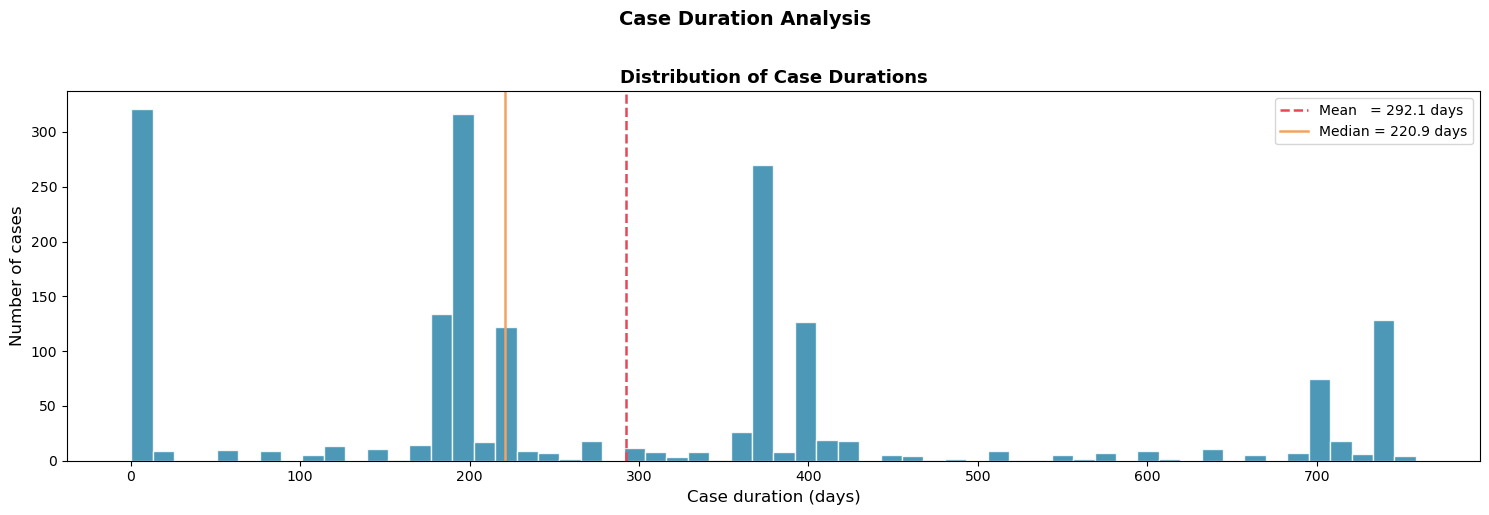

Cases with duration less than 1 day : 161
Cases longer than 30 days           : 1,490
Cases longer than 365 days          : 745
Mean/Median gap (days)              : 71.19


In [13]:
duration_df = (
    all_log
    .groupby('case:concept:name')['time:timestamp']
    .agg(['min', 'max'])
    .rename(columns={'min': 'start', 'max': 'end'})
)
duration_df['start'] = pd.to_datetime(duration_df['start'], utc=True)
duration_df['end']   = pd.to_datetime(duration_df['end'],   utc=True)

# Transform the values into hours and days
dur_d = (duration_df['end'] - duration_df['start']).dt.total_seconds() / 3600 / 24

# Plot the distribution of case durations
fig, ax = plt.subplots(figsize=(15, 5))

ax.hist(dur_d, bins=60, color='#2E86AB', edgecolor='white', alpha=0.85)
ax.axvline(dur_d.mean(),   color='#E84855', linestyle='--', linewidth=1.8,
           label=f'Mean   = {dur_d.mean():.1f} days')
ax.axvline(dur_d.median(), color='#F4A261', linestyle='-',  linewidth=1.8,
           label=f'Median = {dur_d.median():.1f} days')
ax.set_xlabel('Case duration (days)', fontsize=12)
ax.set_ylabel('Number of cases',      fontsize=12)
ax.set_title('Distribution of Case Durations', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)

plt.suptitle('Case Duration Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Additional detail
zero_dur = (dur_d <= 1).sum()
over30d  = (dur_d > 30).sum()
over365d  = (dur_d > 365).sum()
print(f'Cases with duration less than 1 day : {zero_dur:,}')
print(f'Cases longer than 30 days           : {over30d:,}')
print(f'Cases longer than 365 days          : {over365d:,}')
print(f'Mean/Median gap (days)              : {dur_d.mean() - dur_d.median():.2f}')

The distribution is strongly right-skewed, with the mean much higher than the median, indicating the presence of very long cases pulling the average up. The histogram shows four clear groups: a lot of very short cases (≈0 days, probably applications that got rejected right after the credit check) and three peaks around 0.5, 1 and 2 years. These three peaks match exactly the three values we see in `loan_term_years`. So the log clearly contains different types of cases mixed together (rejected ones vs accepted-and-repaid ones, and within the accepted ones, three different loan terms).

## <b>Question 2</b>: General Visual Analytics & Exploration
To deepen the understanding of the event data, we apply techniques from visual analytics. 

### <b>2a.</b> Variant Analysis
Using a variant exploration, select five variants and
report their frequencies. Include a visualization of one variant and annotate it to
highlight repetitive or similar patterns. Compare the five variants with respect to:
- contained activities
- length
- attributes
Provide a concise description. 

In [14]:
# Sort variants by frequency (descending)
variants = pm4py.get_variants(all_log)
sorted_variants = sorted(variants.items(), key=lambda x: -x[1])

# Select five variants
# V1: most frequent variant
v1 = sorted_variants[0]

# V2: most frequent variant ending in "Repayment Completed" that is also longer than V1
v2 = next([v, c] for v, c in sorted_variants
          if v[-1] == "Repayment Completed" and len(v) > len(v1[0]))

# V3: most frequent rejected variant that contains "Decide Loan Application"
v3 = next([v, c] for v, c in sorted_variants
          if v[-1] == "Send Rejection Notification" and "Decide Loan Application" in v)

# V4: most frequent rejected variant WITHOUT "Decide Loan Application" (auto-rejection)
v4 = next([v, c] for v, c in sorted_variants
          if v[-1] == "Send Rejection Notification" and "Decide Loan Application" not in v)

# V5: mid-frequency variant 
v5 = sorted_variants[len(sorted_variants) // 2]

selected_variants = [v1, v2, v3, v4, v5]

# Print the summary table
total_cases = all_log['case:concept:name'].nunique()

print(f'{'Rank':<6} {'Frequency':>10} {'% of cases':>13} {'Length':>8}   Variant label')
print('-' * 100)
for rank, (variant, cases) in enumerate(selected_variants):
    freq = cases if isinstance(cases, int) else len(cases)
    pct = freq / total_cases * 100
    length = len(variant)
    label = f'V{rank+1}: {" → ".join(variant[:3])}{'...' if length > 3 else ''}'
    print(f'{rank+1:<6} {freq:>10,} {pct:>10.2f}%  {length:>7}     {label}')

Rank    Frequency    % of cases   Length   Variant label
----------------------------------------------------------------------------------------------------
1              80       4.40%       23     V1: Application Registered → Retrieve Identity Document → Retrieve Internal Log Data...
2              50       2.75%       29     V2: Application Registered → Retrieve Identity Document → Retrieve Internal Log Data...
3              38       2.09%       13     V3: Application Registered → Retrieve Identity Document → Retrieve Internal Log Data...
4              20       1.10%       11     V4: Application Registered → Retrieve Identity Document → Retrieve Internal Log Data...
5               1       0.05%       41     V5: Application Registered → Retrieve Identity Document → Verify ID Automatically...


In [15]:
# Build a comparison DataFrame for each selected variant
attr_cols = ['risk_score','credit_score','code','loan_decision',
             'auto_id_verification_outcome','manual_id_verification_outcome',
             'transfer_amount','interest','loan_term_years','repaid_amount']

case_act_seq = (all_log.sort_values("time:timestamp")
                   .groupby("case:concept:name")["concept:name"]
                   .apply(tuple))

rows = []
for rank, (variant, cases) in enumerate(selected_variants):
    activities = list(variant)
    cid = case_act_seq[case_act_seq == variant].index.tolist()[0]
    sub = all_log[all_log["case:concept:name"] == cid]
    dur = sub["time:timestamp"].max() - sub["time:timestamp"].min()
    populated = {col: sub.loc[sub[col].notna(), col].astype(str).unique().tolist()
                 for col in attr_cols if sub[col].notna().any()}

    rows.append({
        'Variant'    : rank+1,
        'Frequency'  : cases,
        'Length'     : len(variant),
        'First act'  : activities[0],
        'Last act'   : activities[-1],
        'Unique acts': len(set(activities)),
        'Repeated acts': 'Yes' if len(set(activities)) < len(activities) else 'No',
        'Example case': cid,
        'Example duration': str(dur),
        'Populated attributes': populated,
    })

cmp_df = pd.DataFrame(rows).set_index('Variant')
cmp_df.head(5)

,Frequency,Length,First act,Last act,Unique acts,Repeated acts,Example case,Example duration,Populated attributes
Variant,,,,,,,,,
1,80,23,Application Registered,Repayment Completed,18,Yes,101-1919,189 days 16:29:08,"{'risk_score': ['0.17'], 'credit_score': ['828..."
2,50,29,Application Registered,Repayment Completed,18,Yes,101-465,372 days 08:42:05,"{'risk_score': ['0.17'], 'credit_score': ['828..."
3,38,13,Application Registered,Send Rejection Notification,13,No,147-1907,0 days 17:05:02,"{'risk_score': ['0.32'], 'credit_score': ['676..."
4,20,11,Application Registered,Send Rejection Notification,11,No,195-1320,0 days 23:05:01,"{'risk_score': ['0.69'], 'credit_score': ['314..."
5,1,41,Application Registered,Repayment Completed,19,Yes,388-1984,704 days 22:08:04,"{'risk_score': ['0.21'], 'credit_score': ['785..."


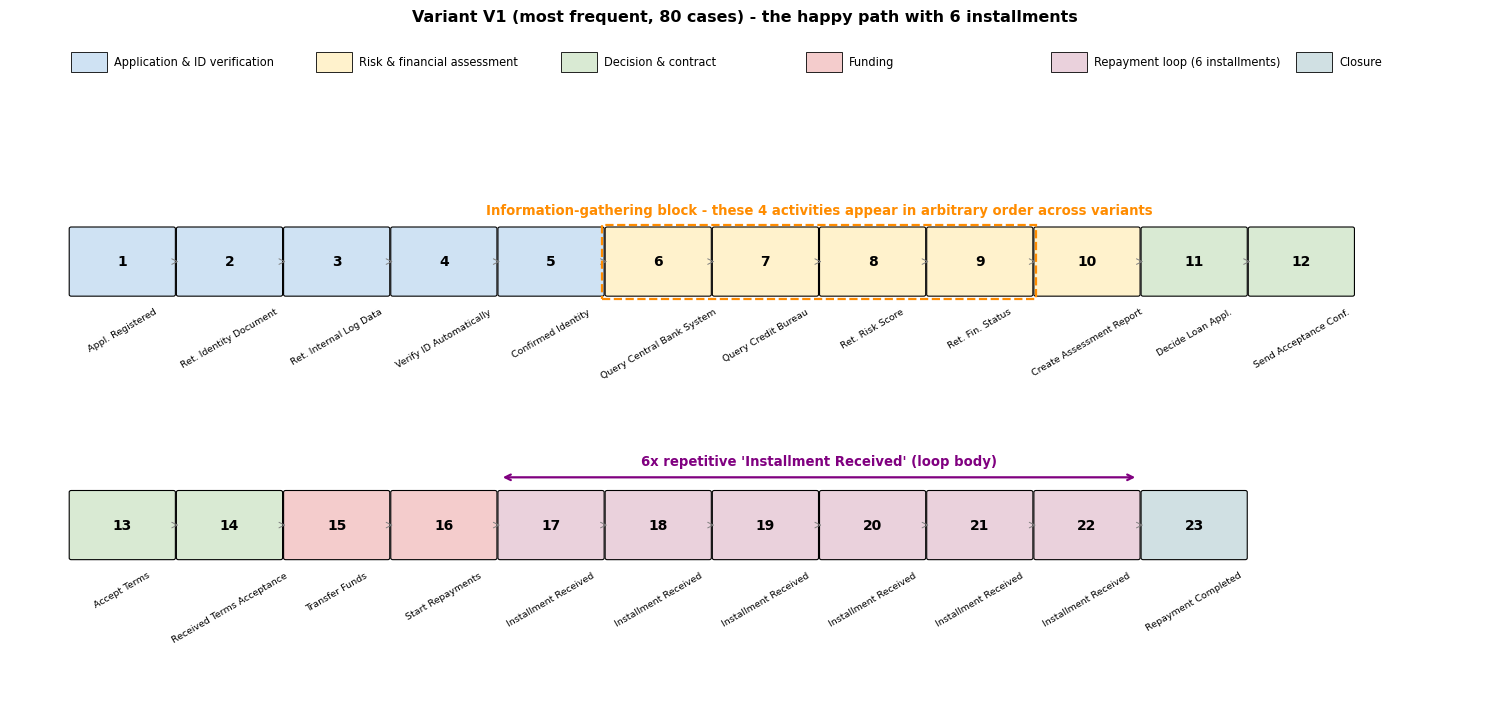

In [16]:
# Annotated visualization of V1 - we highlight the two patterns that recur across many other variants of the log:
variant_v1 = selected_variants[0][0]

phases = [
    ("Application & ID verification",   range(0,5),   "#cfe2f3"),
    ("Risk & financial assessment",     range(5,10),  "#fff2cc"),
    ("Decision & contract",             range(10,14), "#d9ead3"),
    ("Funding",                         range(14,16), "#f4cccc"),
    ("Repayment loop (6 installments)",  range(16,22), "#ead1dc"),
    ("Closure",                         range(22,23), "#d0e0e3"),
]

fig, ax = plt.subplots(figsize=(15, 7.2))
ax.set_xlim(-0.2, 14.2); ax.set_ylim(-0.2, 8); ax.axis("off")

box_w, box_h, per_row = 1.0, 0.8, 12
y_top, y_bot = 4.7, 1.5
positions = [(0.4 + (i % per_row)*1.05, y_top if i < per_row else y_bot)
             for i in range(len(variant_v1))]
color_of = {i: c for label, idx_range, c in phases for i in idx_range}

for i, (x, y) in enumerate(positions):
    ax.add_patch(FancyBboxPatch((x, y), box_w, box_h, boxstyle="round,pad=0.02",
                                 linewidth=0.8, facecolor=color_of[i],
                                 edgecolor="black"))
    ax.text(x + box_w/2, y + box_h/2, str(i+1),
            ha="center", va="center", fontsize=10, weight="bold")
    short = (variant_v1[i].replace("Retrieve ", "Ret. ")
                          .replace("Application", "Appl.")
                          .replace("Confirmation", "Conf.")
                          .replace("Customer Global ", "")
                          .replace("Financial Status", "Fin. Status"))
    ax.text(x + box_w/2, y - 0.15, short,
            ha="center", va="top", fontsize=6.8, rotation=30)

# horizontal arrows within rows
for i in range(len(variant_v1) - 1):
    if i == per_row - 1:
        continue
    (x1, y1), (x2, y2) = positions[i], positions[i+1]
    ax.add_patch(FancyArrowPatch((x1+box_w, y1+box_h/2), (x2, y2+box_h/2),
                  arrowstyle="->", mutation_scale=10, color="grey", lw=0.7))

# annotation: 6x repetitive installment loop
inst_idx = list(range(16, 22))
xs = [positions[i][0] for i in inst_idx]
y_lab = positions[inst_idx[0]][1] + box_h + 0.18
ax.annotate("", xy=(xs[-1] + box_w, y_lab), xytext=(xs[0], y_lab),
            arrowprops=dict(arrowstyle="<->", color="purple", lw=1.6))
ax.text((xs[0] + xs[-1] + box_w)/2, y_lab + 0.15,
        "6x repetitive 'Installment Received' (loop body)",
        ha="center", color="purple", fontsize=9.5, weight="bold")

# annotation: information-gathering block
info_idx = list(range(5, 9))
xs2 = [positions[i][0] for i in info_idx]
y_box_top = positions[info_idx[0]][1] + box_h
ax.add_patch(Rectangle((xs2[0]-0.05, positions[info_idx[0]][1]-0.05),
                        xs2[-1]+box_w-xs2[0]+0.1, box_h+0.10,
                        fill=False, edgecolor="darkorange", lw=1.6, ls="--"))
ax.text((xs2[0] + xs2[-1] + box_w)/2, y_box_top + 0.18,
        "Information-gathering block - these 4 activities appear in arbitrary order across variants",
        ha="center", color="darkorange", fontsize=9.5, weight="bold")

# legend
y_leg = 7.4
for k, (label, _, col) in enumerate(phases):
    x_l = 0.4 + k * 2.4
    ax.add_patch(Rectangle((x_l, y_leg), 0.35, 0.25,
                  facecolor=col, edgecolor="black", lw=0.6))
    ax.text(x_l + 0.42, y_leg + 0.12, label, va="center", fontsize=8.2)

ax.set_title("Variant V1 (most frequent, 80 cases) - the happy path with 6 installments",
             fontsize=11.5, weight="bold", y=0.99)
plt.tight_layout(); plt.show()

In [17]:
# Build a comparison table along: contained activities, length, and the domain-specific attributes that are populated in an example case of each variant.
labels = {
    "V1 (happy path, 6 installments)":   v1[0],
    "V2 (happy path, 12 installments)":  v2[0],
    "V3 (rejected AFTER Decide)":        v3[0],
    "V4 (rejected BEFORE Decide)":       v4[0],
    "V5 (mid frequency variant)":        v5[0],
}

print("\nPopulated domain-specific attributes (one example case per variant):")
for i, r in enumerate(rows):
    print(f"\n{list(labels.keys())[i]}  (case {r['Example case']}):")
    for k, vals in r["Populated attributes"].items():
        print(f"   {k:32s} -> {vals}")


Populated domain-specific attributes (one example case per variant):

V1 (happy path, 6 installments)  (case 101-1919):
   risk_score                       -> ['0.17']
   credit_score                     -> ['828.37']
   loan_decision                    -> ['accept']
   auto_id_verification_outcome     -> ['valid']
   transfer_amount                  -> ['500.0']
   interest                         -> ['0.05']
   loan_term_years                  -> ['0.5']
   repaid_amount                    -> ['84.55', '77.25']

V2 (happy path, 12 installments)  (case 101-465):
   risk_score                       -> ['0.17']
   credit_score                     -> ['828.37']
   loan_decision                    -> ['accept']
   auto_id_verification_outcome     -> ['valid']
   transfer_amount                  -> ['500.0']
   interest                         -> ['0.05']
   loan_term_years                  -> ['1.0']
   repaid_amount                    -> ['42.8', '29.199999999999932']

V3 (rejected AFTE

In [18]:
cmp_df

,Frequency,Length,First act,Last act,Unique acts,Repeated acts,Example case,Example duration,Populated attributes
Variant,,,,,,,,,
1,80,23,Application Registered,Repayment Completed,18,Yes,101-1919,189 days 16:29:08,"{'risk_score': ['0.17'], 'credit_score': ['828..."
2,50,29,Application Registered,Repayment Completed,18,Yes,101-465,372 days 08:42:05,"{'risk_score': ['0.17'], 'credit_score': ['828..."
3,38,13,Application Registered,Send Rejection Notification,13,No,147-1907,0 days 17:05:02,"{'risk_score': ['0.32'], 'credit_score': ['676..."
4,20,11,Application Registered,Send Rejection Notification,11,No,195-1320,0 days 23:05:01,"{'risk_score': ['0.69'], 'credit_score': ['314..."
5,1,41,Application Registered,Repayment Completed,19,Yes,388-1984,704 days 22:08:04,"{'risk_score': ['0.21'], 'credit_score': ['785..."


The five variants have very different lengths (11–41 events) but reuse the same building blocks. All five start with the same five activities (application registration and ID verification), then go through the same four information-gathering activities, and only differ in what happens after that: V1, V2 and V5 go through the contract, funding and repayment phases and end with `Repayment Completed` (V5 is much longer because of a bigger number of installments), V3 follows the manual rejection branch (`Decide Loan Application` → `Reject Application` → `Send Rejection Notification`), and V4 is auto-rejected and skips `Decide Loan Application` entirely. The length of each variant depends mostly on the number of `Installment Received` events: 6 in V1, 12 in V2, around 23 in V5, and 0 in the rejection variants. V1, V2 and V5 carry the full set of attributes for an accepted loan (`loan_decision = accept`, `interest`, `loan_term_years`, `transfer_amount`, `repaid_amount`), while V3 and V4 only carry the rejection `code` (MLA and LCS) and very different `risk_score` values (0.32 vs. 0.69), which fits with the fact that a high risk score leads to auto-rejection without a manual decision.

### <b>2b.</b>  DFG
Construct a frequency-annotated Directly-Follows Graph (DFG) using the event log.
Briefly describe the graph and discuss the insights gained. 

In [19]:
# Discover the frequency DFG
dfg, start_acts, end_acts = pm4py.discover_directly_follows_graph(all_log)

print(f'Number of DFG edges : {len(dfg):,}')
print(f'Start activities : {list(start_acts.keys())}')
print(f'End activities : {list(end_acts.keys())}')

# Top-20 most frequent edges
top_edges = sorted(dfg.items(), key=lambda x: x[1], reverse=True)[:20]
print('\nTop-20 most frequent directly-follows pairs:')
print(f'  {"From activity":<45} {"To activity":<45} {"Frequency":>10}')
print('-' * 105)
for (src, tgt), freq in top_edges:
    print(f'  {src:<45} {tgt:<45} {freq:>10,}')

Number of DFG edges : 81
Start activities : ['Application Registered']
End activities : ['Send Rejection Notification', 'Send to Collections', 'Repayment Completed']

Top-20 most frequent directly-follows pairs:
  From activity                                 To activity                                    Frequency
---------------------------------------------------------------------------------------------------------
  Installment Received                          Installment Received                              13,990
  Application Registered                        Retrieve Identity Document                         1,820
  Create Assessment Report                      Decide Loan Application                            1,671
  Accept Terms                                  Received Terms Acceptance                          1,499
  Decide Loan Application                       Send Acceptance Confirmation                       1,499
  Received Terms Acceptance                     Tran

In [20]:
# Build the visualisation for the frequency-annotated DFG
gviz = dfg_visualizer.apply(
    dfg,
    log=all_log,
    variant=dfg_visualizer.Variants.FREQUENCY,      # darker = more frequent
    parameters={
        'start_activities': start_acts,
        'end_activities' : end_acts,
        'format' : 'png',
        'size' : (6, 4)
    }
)

# Save the DFG image
dfg_visualizer.save(gviz, "images/dfg_frequency.png")

''

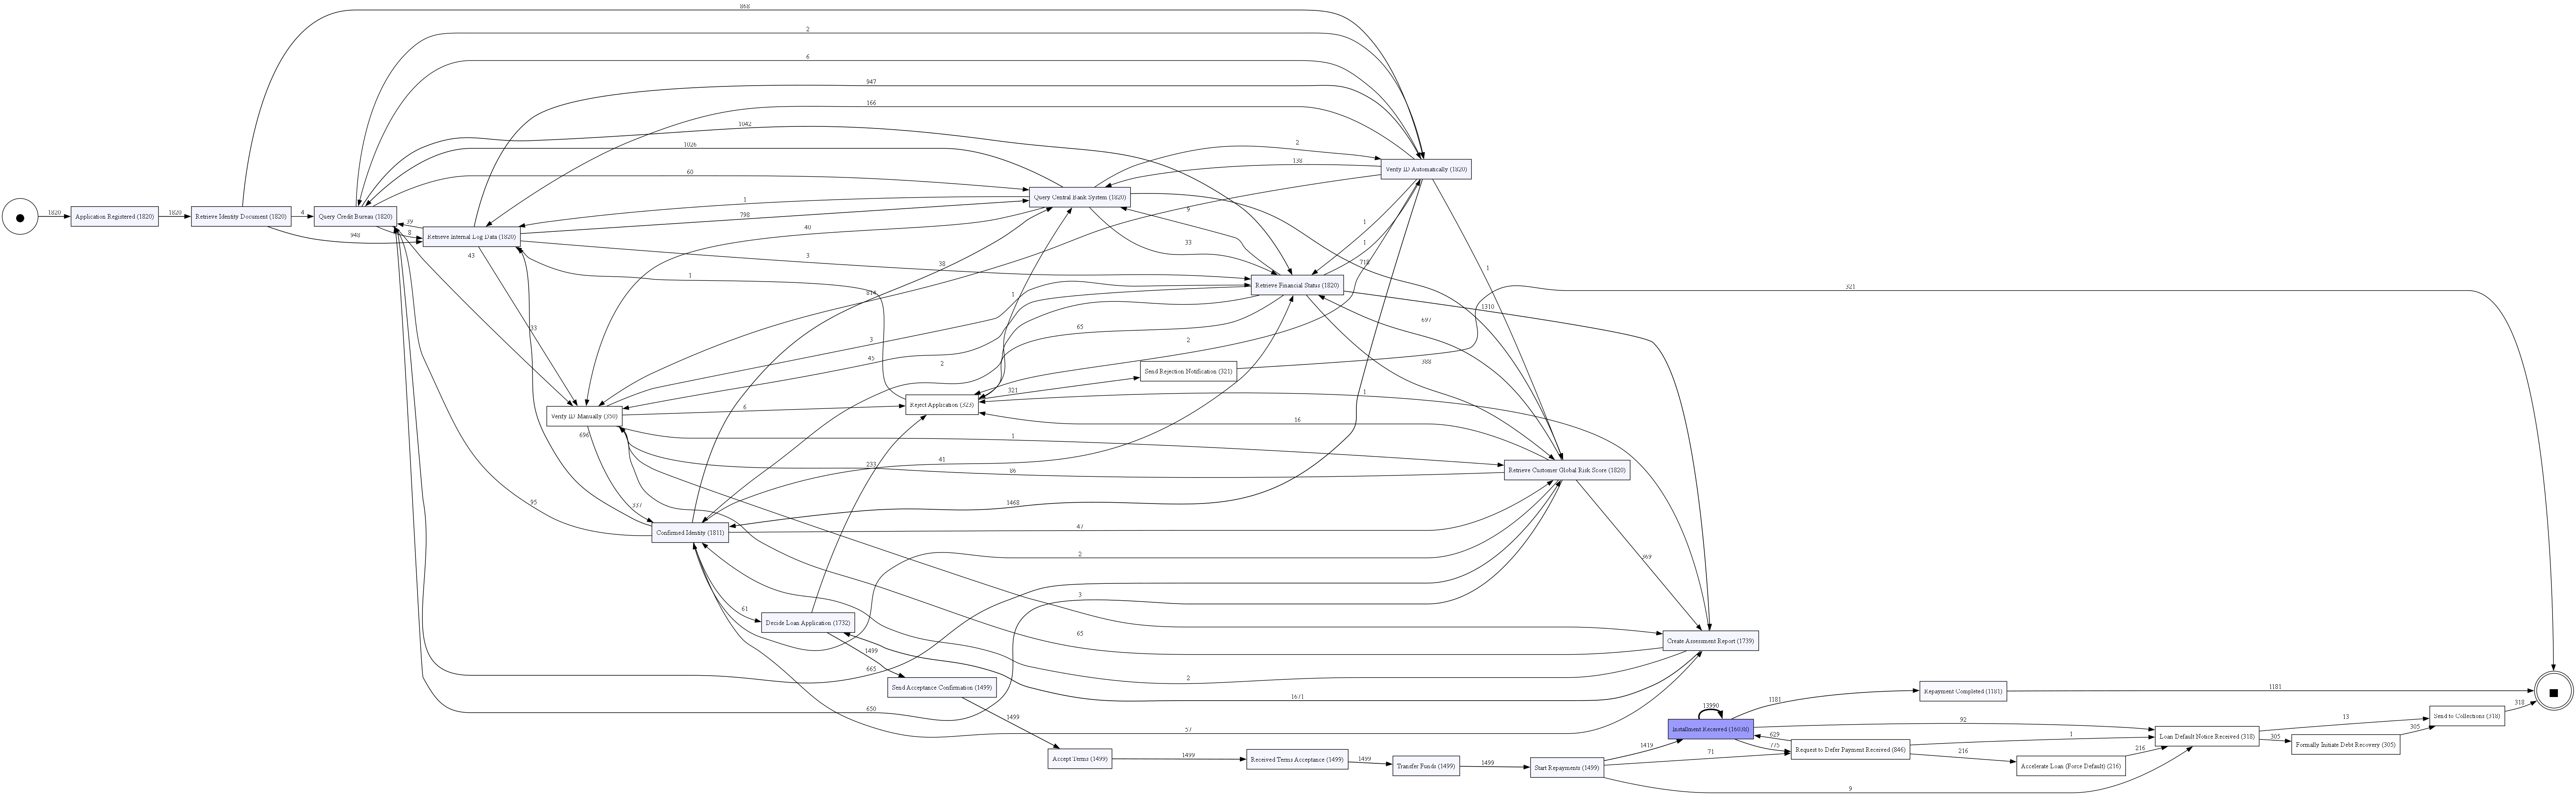

In [21]:
# Display the DFG 
Image(gviz.render(), width=1800)

In [22]:
# Compute in-degree and out-degree for each node 
out_degree = defaultdict(int)
in_degree = defaultdict(int)
out_freq = defaultdict(int)   # total outgoing frequency
in_freq = defaultdict(int)    # total incoming frequency

for (src, tgt), freq in dfg.items():
    out_degree[src] += 1
    in_degree[tgt] += 1
    out_freq[src] += freq
    in_freq[tgt] += freq

all_activities = sorted(set(list(out_degree) + list(in_degree)))

# Quantitative DFG summary
summary_df = pd.DataFrame({
    'Activity'     : all_activities,
    'Out-degree'   : [out_degree[a] for a in all_activities],
    'In-degree'    : [in_degree[a] for a in all_activities],
    'Out-frequency': [out_freq[a] for a in all_activities],
    'In-frequency' : [in_freq[a] for a in all_activities],
    'Is start'     : [a in start_acts for a in all_activities],
    'Is end'       : [a in end_acts for a in all_activities],
}).sort_values('Out-frequency', ascending=False)

print('Activity-level DFG statistics (sorted by outgoing frequency):')
summary_df

Activity-level DFG statistics (sorted by outgoing frequency):


,Activity,Out-degree,In-degree,Out-frequency,In-frequency,Is start,Is end
7,Installment Received,4,3,16038,16038,False,False
2,Application Registered,1,0,1820,0,True,False
9,Query Central Bank System,6,6,1820,1820,False,False
16,Retrieve Financial Status,7,7,1820,1820,False,False
18,Retrieve Internal Log Data,5,6,1820,1820,False,False
24,Verify ID Automatically,8,5,1820,1820,False,False
15,Retrieve Customer Global Risk Score,6,6,1820,1820,False,False
10,Query Credit Bureau,6,6,1820,1820,False,False
17,Retrieve Identity Document,3,1,1820,1820,False,False
3,Confirmed Identity,7,5,1811,1811,False,False


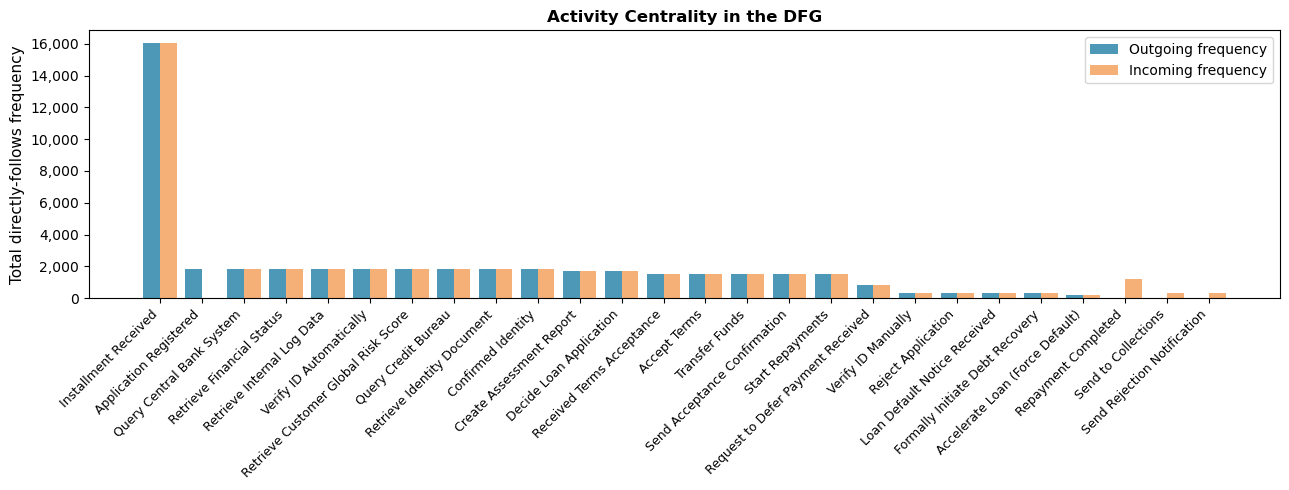

In [23]:
# Plot activity in/out frequency
fig, ax = plt.subplots(figsize=(13, 5))

acts_sorted = summary_df['Activity'].tolist()
out_f_sorted = summary_df['Out-frequency'].tolist()
in_f_sorted = summary_df['In-frequency'].tolist()

x = np.arange(len(acts_sorted))
w = 0.4

ax.bar(x - w/2, out_f_sorted, width=w, color='#2E86AB', alpha=0.85, label='Outgoing frequency')
ax.bar(x + w/2, in_f_sorted,  width=w, color='#F4A261', alpha=0.85, label='Incoming frequency')

ax.set_xticks(x)
ax.set_xticklabels(acts_sorted, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Total directly-follows frequency', fontsize=11)
ax.set_title('Activity Centrality in the DFG', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

 The DFG has one start activity (`Application Registered`, all 1 820 cases) and three end activities for the three possible outcomes: `Repayment Completed` (1 181), `Send Rejection Notification` (321) and `Send to Collections` (318), so about 65 % of loans are repaid, 18 % are rejected up front and 17 % default after acceptance. The strongest edge by far is the `Installment Received` self-loop with 13 990 occurrences (about 30 % of all events), followed by the fixed sequence `Decide Loan Application` → `Send Acceptance Confirmation` → `Accept Terms` → `Received Terms Acceptance` → `Transfer Funds` → `Start Repayments` with around 1 499 occurrences each, which is the standard contract and funding part of the process. The four information-gathering activities (`Query Central Bank System`, `Query Credit Bureau`, `Retrieve Customer Global Risk Score`, `Retrieve Financial Status`), in contrast, are connected to each other in many directions, which means they can run in parallel — this matches what we already saw in question 2a, where their order was different, which explains why we have so many distinct variants. Finally, the edge `Verify ID Automatically` → `Verify ID Manually` shows that there is a fallback path: when automatic ID verification doesn't work, a manual check is done instead, which is also why 243 variants contain `Verify ID Manually`.

## <b>Question 3</b>: Use Case-Specific Visual Analytics & Exploration

### <b>3a.</b> MID Rejection Variants
For the MID reason code, filter the event log all.xes to retain only cases that were
rejected with the MID code. List all trace variants in the filtered log along with their
frequencies. What do you learn about the process? Are all cases terminated
immediately after a rejection due to MID? Discuss your findings from an efficiency
perspective. (approx. 2-3 sentences)


In [24]:
# Get cases which are rejected due to MID
mid_all_log = pm4py.filter_event_attribute_values(all_log, "code", ["MID"], level="case", retain=True)
total_cases = len(mid_all_log['case:concept:name'].unique())
print(f"Total cases rejected due to MID: {total_cases}\n")

# Extract and sort variants
variants_mid = pm4py.get_variants(mid_all_log)
variants_sorted_mid = sorted(variants_mid.items(), key=lambda x: x[1], reverse=True)

print("--- MID Trace Variants & Frequencies ---")
for i, (variant, count) in enumerate(variants_sorted_mid):
    print(f"Variant {i+1} (Frequency: {count} cases):")
    
    if isinstance(variant, str):
        print(f"  Sequence: {variant.replace(',', ' -> ')}\n")
    else:
        print(f"  Sequence: {' -> '.join(variant)}\n")

Total cases rejected due to MID: 9

--- MID Trace Variants & Frequencies ---
Variant 1 (Frequency: 4 cases):
  Sequence: Application Registered -> Retrieve Identity Document -> Retrieve Internal Log Data -> Verify ID Automatically -> Query Central Bank System -> Query Credit Bureau -> Retrieve Customer Global Risk Score -> Retrieve Financial Status -> Create Assessment Report -> Verify ID Manually -> Reject Application -> Send Rejection Notification

Variant 2 (Frequency: 1 cases):
  Sequence: Application Registered -> Retrieve Identity Document -> Verify ID Automatically -> Retrieve Internal Log Data -> Query Central Bank System -> Query Credit Bureau -> Retrieve Financial Status -> Retrieve Customer Global Risk Score -> Create Assessment Report -> Verify ID Manually -> Reject Application -> Send Rejection Notification

Variant 3 (Frequency: 1 cases):
  Sequence: Application Registered -> Retrieve Identity Document -> Retrieve Internal Log Data -> Verify ID Automatically -> Reject App

Out of the 9 cases rejected with the MID code, **only 2 cases** are rejected directly after `Verify ID Automatically` (Variants 3 and 4) — the other **7 cases** still go through the full information-gathering block (`Query Central Bank System`, `Query Credit Bureau`, `Retrieve Customer Global Risk Score`, `Retrieve Financial Status`) and `Create Assessment Report` before being rejected. This is inefficient, because the credit-related queries cost time and money but are not needed when the application documents are already known to be missing or incorrect — the MID check should run first and stop the process immediately.

### <b>3b.</b> Risk Scores of LCS-Rejected Cases
Load the event log lcs-rejected-customers.xes. Give the case id and the risk score of
the `Retrieve Customer Global Risk Score` event for:
- two cases that were rejected with reason code LCS after `Decide Loan Application`, and
- two cases that were rejected with reason code LCS before, i.e., without `Decide Loan Application`.


In [25]:
# Load lcs sublog
lcs_rejected_customers = pm4py.convert_to_event_log(lcs_rejected_customers)

cases_after_decide = []
cases_without_decide = []

# Loop through the logs 

for trace in lcs_rejected_customers:
    case_id = trace.attributes.get('concept:name', 'Unknown')
    
    # Store current activities and codes
    activities = [event['concept:name'] for event in trace]
    codes = [event.get('code', None) for event in trace]
    
    # Check if this case was actually rejected with LCS
    if 'LCS' in codes:
        score_info = "Not Found"
        
        # Check for all events in the case
        for event in trace:
            # Search for riskscore
            if event['concept:name'] == 'Retrieve Customer Global Risk Score':
                # Only get important columns
                score_info = {k: v for k, v in event.items() if k not in ['concept:name', 'time:timestamp', 'code'] and str(v) != 'nan'}
                break # Stop searching this trace once we find it
                
        # Sort if decide loan application is included
        if 'Decide Loan Application' in activities:
            cases_after_decide.append((case_id, score_info))
        else:
            cases_without_decide.append((case_id, score_info))

# Print the required 2 cases for each prompt
print("--- 2 Cases Rejected (LCS) AFTER 'Decide Loan Application' ---")
for case_id, score in cases_after_decide[:2]:
    print(f"Case ID: {case_id} | Risk Score Data: {score}")

print("\n--- 2 Cases Rejected (LCS) BEFORE 'Decide Loan Application' ---")
for case_id, score in cases_without_decide[:2]:
    print(f"Case ID: {case_id} | Risk Score Data: {score}")

--- 2 Cases Rejected (LCS) AFTER 'Decide Loan Application' ---
Case ID: 464-758 | Risk Score Data: {'org:resource': 'External Information Resource', 'lifecycle:transition': 'complete', 'risk_score': '0.26'}
Case ID: 629-1006 | Risk Score Data: {'org:resource': 'External Information Resource', 'lifecycle:transition': 'complete', 'risk_score': '0.06'}

--- 2 Cases Rejected (LCS) BEFORE 'Decide Loan Application' ---
Case ID: 470-16 | Risk Score Data: {'org:resource': 'External Information Resource', 'lifecycle:transition': 'complete', 'risk_score': '0.56'}
Case ID: 802-25 | Risk Score Data: {'org:resource': 'External Information Resource', 'lifecycle:transition': 'complete', 'risk_score': '0.52'}


### <b>3c.</b> Projected LCS Variants
Cases can be rejected without the manual `Decide Loan Application` activity if the
risk score of the corresponding customer is too high. Additionally, an assessment based
on internal log data in the `Decide Loan Application` activity may lead to rejection with
the LCS reason code. Project the event log lcs-rejected-customers.xes on the activities
`Reject Application`, `Decide Loan Application` and `Send to Collections`. Which variants
does the filtered log have? Report all variants along with their frequencies.


In [26]:
# Define target activities
target_activities = [
    'Reject Application', 
    'Decide Loan Application', 
    'Send to Collections'
]
# Project the logs, only keep the target events
projected_log = pm4py.filter_event_attribute_values(
    lcs_rejected_customers, 
    "concept:name", 
    target_activities, 
    level="event", 
    retain=True
)

# Get the different variants 
variants_proj = pm4py.get_variants(projected_log)

# Order variants
variants_proj_sorted = sorted(variants_proj.items(), key=lambda x: len(x[1]), reverse=True)


print("--- Projected LCS Trace Variants & Frequencies ---")
for i, (variant, traces) in enumerate(variants_proj_sorted):
    print(f"Variant {i+1} (Frequency: {len(traces)} cases):")
    
    # Format the output beautifully with arrows
    if isinstance(variant, str):
        print(f"  Sequence: {variant.replace(',', ' -> ')}\n")
    else:
        print(f"  Sequence: {' -> '.join(variant)}\n")

--- Projected LCS Trace Variants & Frequencies ---
Variant 1 (Frequency: 79 cases):
  Sequence: Reject Application

Variant 2 (Frequency: 29 cases):
  Sequence: Decide Loan Application -> Reject Application

Variant 3 (Frequency: 22 cases):
  Sequence: Decide Loan Application -> Send to Collections

Variant 4 (Frequency: 7 cases):
  Sequence: Decide Loan Application

Variant 5 (Frequency: 2 cases):
  Sequence: Reject Application -> Reject Application



## <b>Question 4</b>: Process Discovery
After these exploratory perspectives on the process, we want to take a deeper look at the
control flow of the process. As the perfect model or discovery algorithm does not exist, it
makes sense to apply multiple algorithms to different perspectives on the process and
compare their results. Some algorithms handle noise better than others. Some algorithms
have stronger or weaker modeling bias, making it a mix-and-match problem.

### <b>4a.</b> Discover Petri Nets
Before focusing on different perspectives on the processes and creating separate
views, we will try to discover a holistic model of the entire process using out-of-thebox process discovery algorithms.

In [27]:
# Store all models in a list for easy iteration in later sub-questions
models = []

# 1. INDUCTIVE MINER – (noise_threshold = 0.0)
print('1. Inductive Miner (noise=0.0)')
im_net, im_im, im_fm = pm4py.discover_petri_net_inductive(rejected_loans, noise_threshold=0.0)
print(f'   places={len(im_net.places)}  transitions={len(im_net.transitions)}  '
      f'arcs={len(im_net.arcs)}', end='\n\n')
models.append(('IM', im_net, im_im, im_fm, 'Inductive Miner (noise=0.0)'))


# 2. INDUCTIVE MINER INFREQUENT – threshold 0.5
print('2. Inductive Miner infrequent (noise=0.5)')
imf05_net, imf05_im, imf05_fm = pm4py.discover_petri_net_inductive(rejected_loans, noise_threshold=0.5)
print(f'   places={len(imf05_net.places)}  transitions={len(imf05_net.transitions)}  '
      f'arcs={len(imf05_net.arcs)}', end='\n\n')
models.append(('IMf05', imf05_net, imf05_im, imf05_fm, 'IM infrequent (noise=0.5)'))


# 3. INDUCTIVE MINER INFREQUENT – threshold 0.8
print('3. Inductive Miner infrequent (noise=0.8)')
imf08_net, imf08_im, imf08_fm = pm4py.discover_petri_net_inductive(rejected_loans, noise_threshold=0.8)
print(f'   places={len(imf08_net.places)}  transitions={len(imf08_net.transitions)}  '
      f'arcs={len(imf08_net.arcs)}', end='\n\n')
models.append(('IMf08', imf08_net, imf08_im, imf08_fm, 'IM infrequent (noise=0.8)'))


# 4. ILP MINER
print('4. ILP Miner')
ilp_net, ilp_im, ilp_fm = pm4py.discover_petri_net_ilp(rejected_loans)
print(f'   places={len(ilp_net.places)}  transitions={len(ilp_net.transitions)}  '
      f'arcs={len(ilp_net.arcs)}', end='\n\n')
models.append(('ILP', ilp_net, ilp_im, ilp_fm, 'ILP Miner'))


# 5. HEURISTICS MINER
print('5. Heuristics Miner')
heu_net, heu_im, heu_fm = pm4py.discover_petri_net_heuristics(rejected_loans)
print(f'   places={len(heu_net.places)}  transitions={len(heu_net.transitions)}  '
      f'arcs={len(heu_net.arcs)}', end='\n\n')
models.append(('Heu', heu_net, heu_im, heu_fm, 'Heuristics Miner'))

1. Inductive Miner (noise=0.0)
   places=27  transitions=26  arcs=66

2. Inductive Miner infrequent (noise=0.5)
   places=16  transitions=14  arcs=32

3. Inductive Miner infrequent (noise=0.8)
   places=17  transitions=17  arcs=36

4. ILP Miner


discovering Petri net using ILP miner, completed causal relations ::   0%|          | 0/36 [00:00<?, ?it/s]

   places=23  transitions=15  arcs=103

5. Heuristics Miner
   places=31  transitions=36  arcs=90




--- Inductive Miner (noise=0.0) ---
    Places: 27  |  Transitions: 26  |  Arcs: 66


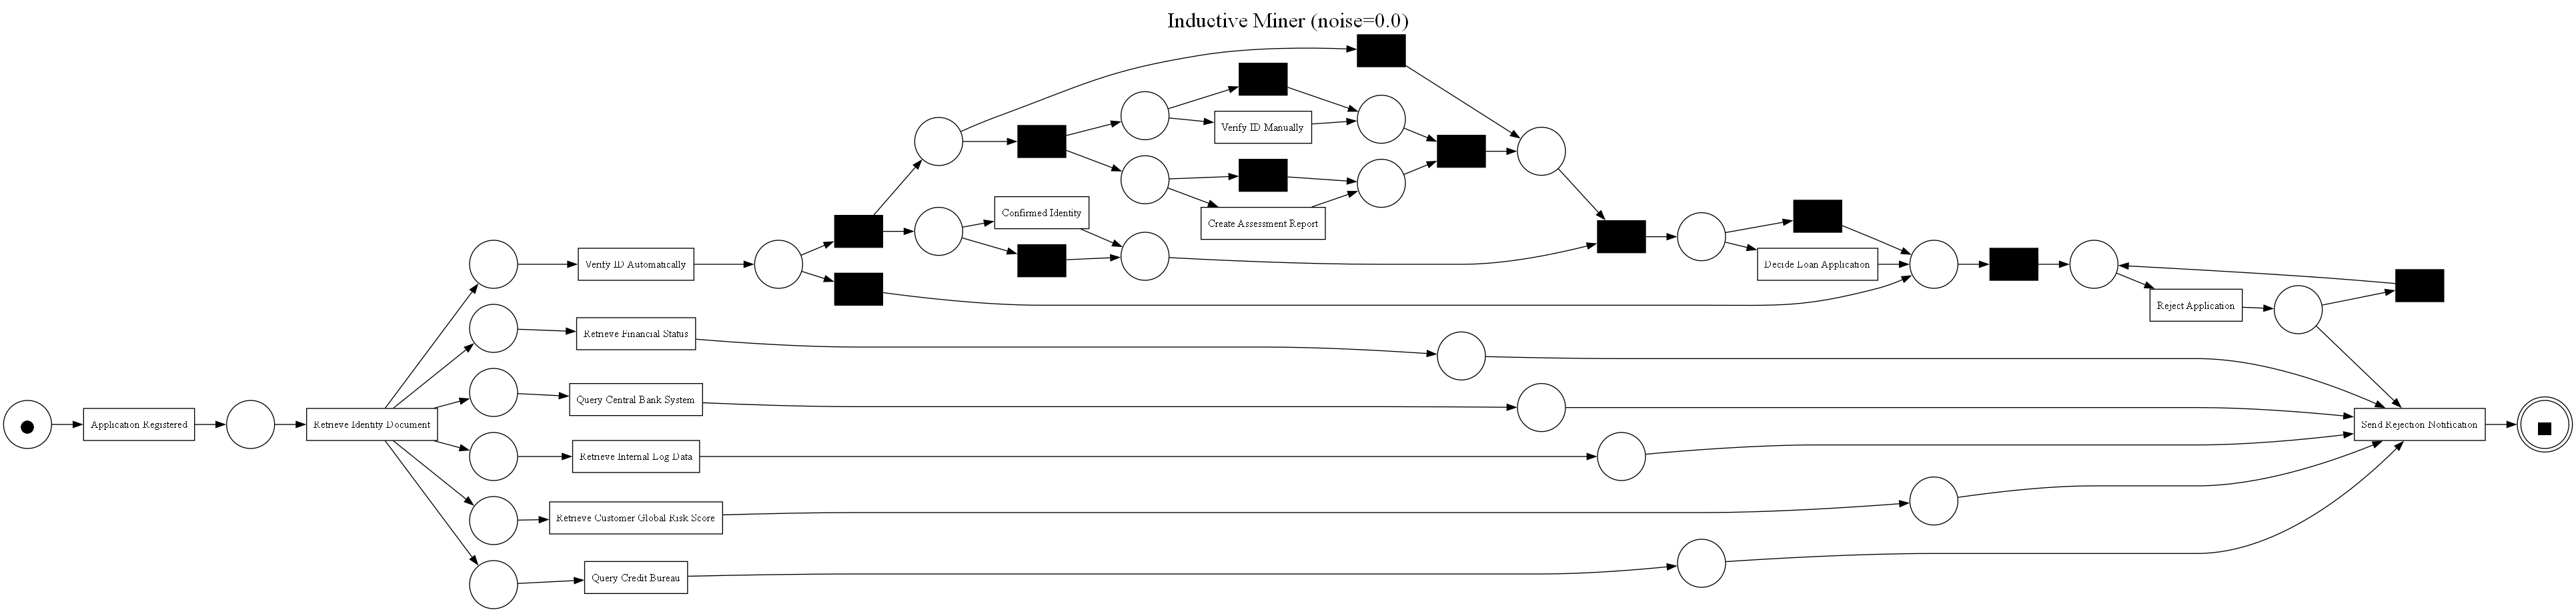


--- IM infrequent (noise=0.5) ---
    Places: 16  |  Transitions: 14  |  Arcs: 32


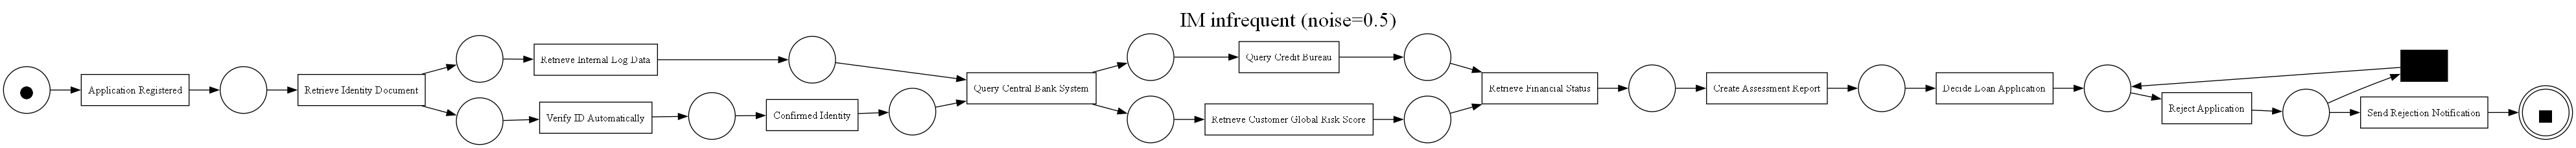


--- IM infrequent (noise=0.8) ---
    Places: 17  |  Transitions: 17  |  Arcs: 36


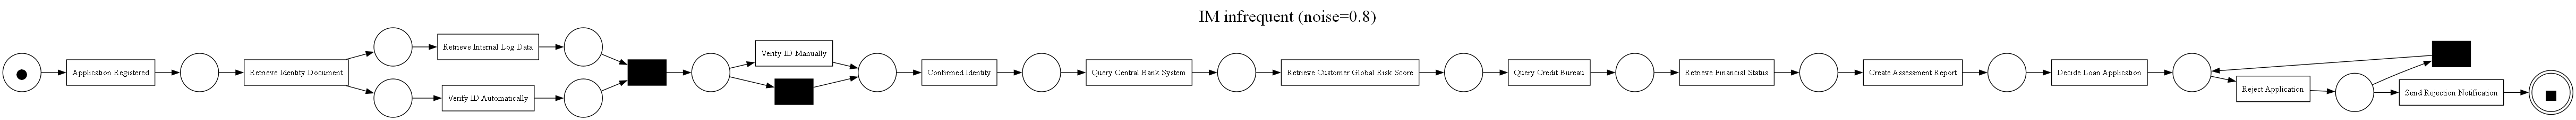


--- ILP Miner ---
    Places: 23  |  Transitions: 15  |  Arcs: 103


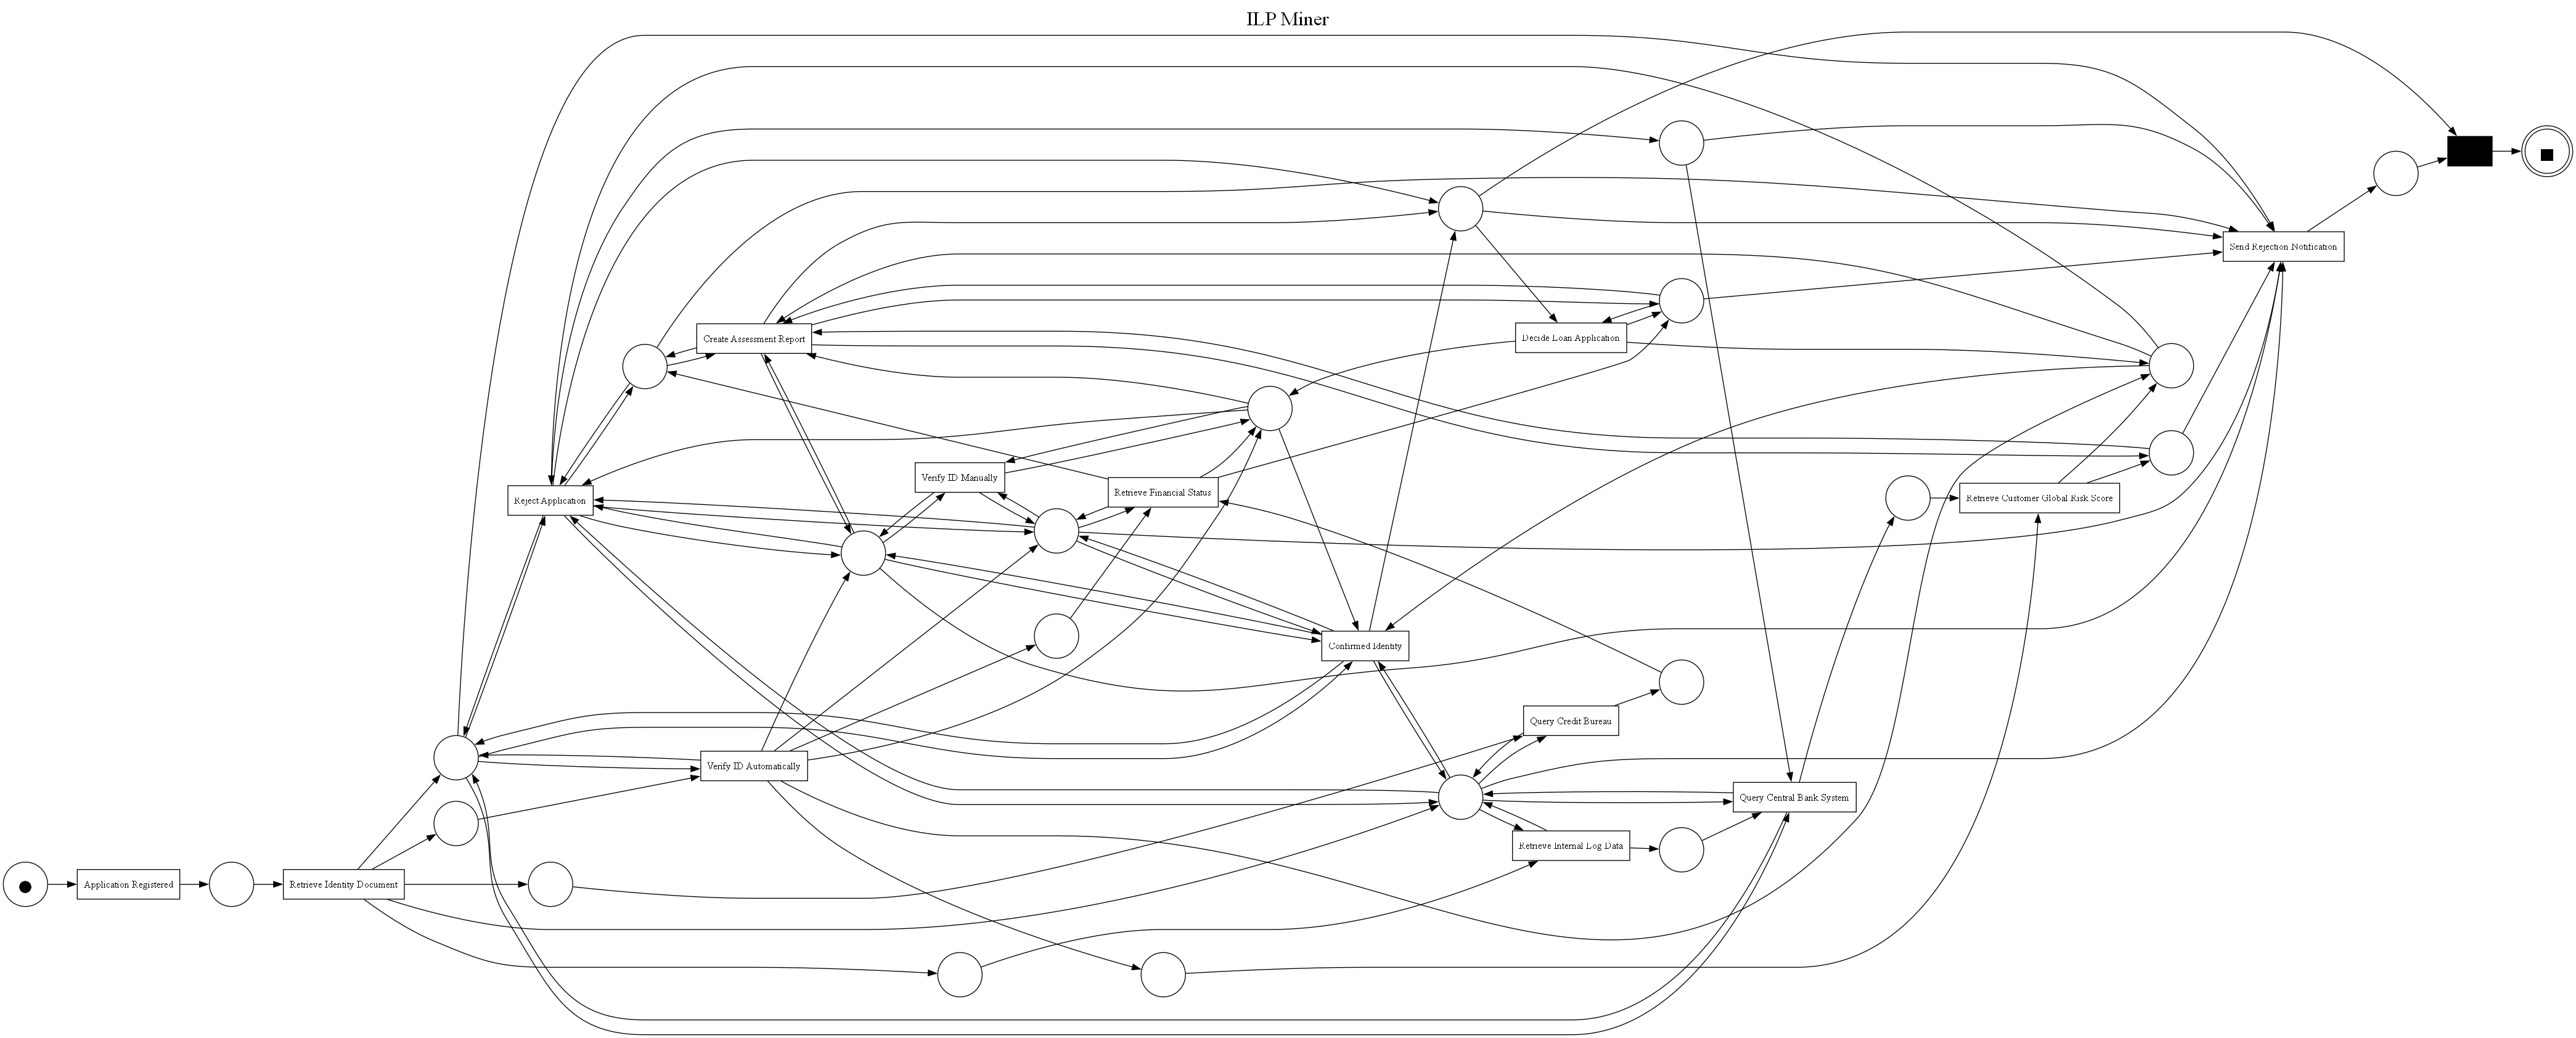


--- Heuristics Miner ---
    Places: 31  |  Transitions: 36  |  Arcs: 90


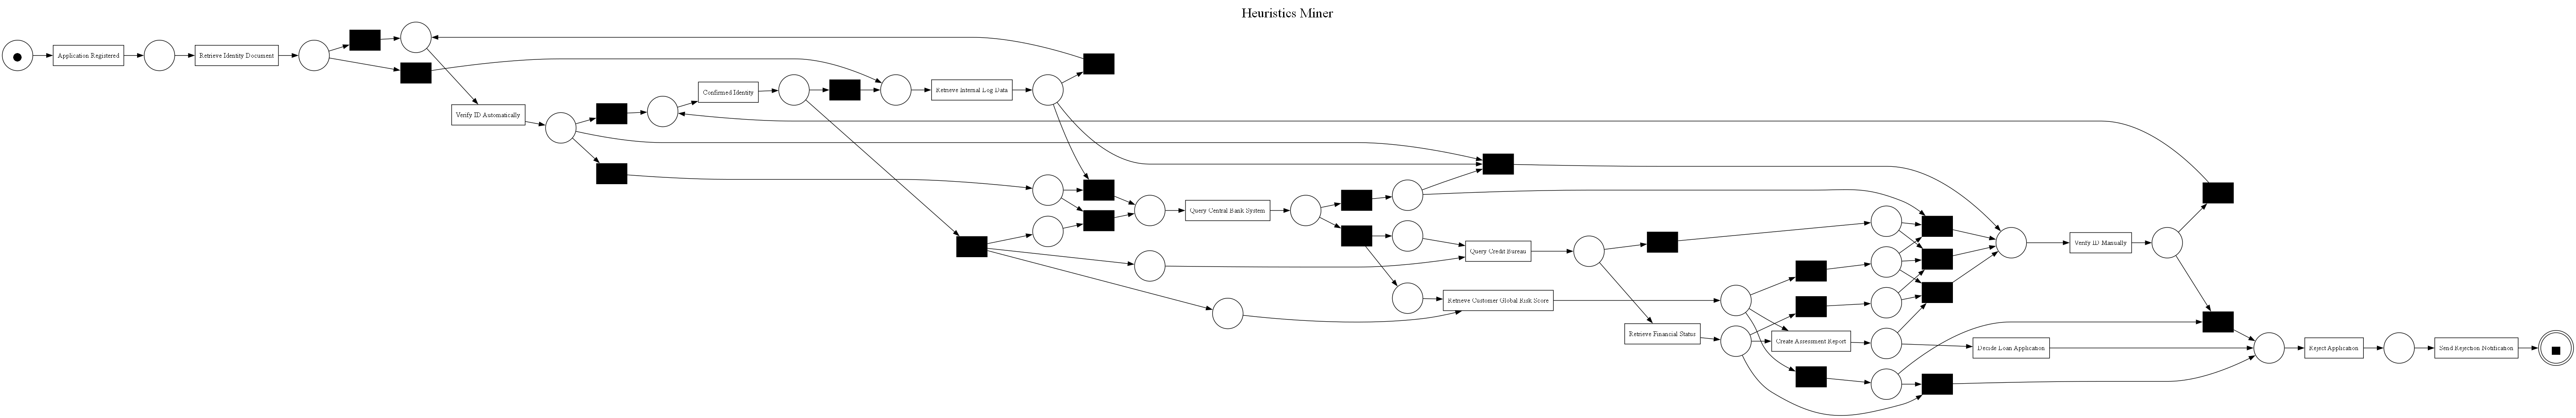

In [28]:
# Render and display all five Petri nets
for key, net, im, fm, title in models:
    path = f'images/model_{key}.png'
    pm4py.save_vis_petri_net(net, im, fm, path, rankdir='LR', graph_title=title)
    print(f'\n--- {title} ---')
    print(f'    Places: {len(net.places)}  |  Transitions: {len(net.transitions)}  |  Arcs: {len(net.arcs)}')
    display(Image(filename=path))

### <b>4b.</b> Soundness, Fitness and Precision
For an initial evaluation of the discovered models, calculate their alignmentbased fitness and precision, if possible (otherwise explain why it is not possible), using
fitness_alignments and precision_alignments. Also, check their soundness with
check_soundness.

A Petri net is a SOUND Workflow Net if:
  1. It has exactly one source place (has tokens only in initial marking)
  2. It has exactly one sink place (receives tokens in final marking)
  3. Every node is on some path from source to sink
  4. No deadlocks: from any reachable marking, the final marking is reachable
  5. No improper completion: at the final marking, no extra tokens exist elsewhere
  6. No dead transitions: every transition can fire in some execution

#### Custom functions to work with timeout

In [29]:
# Function to forcefully kill a process on Windows
def _force_kill_windows(pid):
    PROCESS_TERMINATE = 0x0001
    handle = ctypes.windll.kernel32.OpenProcess(PROCESS_TERMINATE, False, pid)
    if handle:
        result = ctypes.windll.kernel32.TerminateProcess(handle, 1)
        ctypes.windll.kernel32.CloseHandle(handle)
        return result != 0
    return False

In [30]:
def compute_with_timeout(worker, log, net, im, fm, timeout=60):
    ctx = multiprocessing.get_context("spawn")
    result_queue = ctx.Queue()
    p = ctx.Process(target=worker, args=(result_queue, log, net, im, fm))

    p.start()
    pid = p.pid

    deadline = time.time() + timeout
    while time.time() < deadline:
        time.sleep(1)
        if not p.is_alive():
            break

    if p.is_alive():
        print(f"Timeout after {timeout}s")
        killed = _force_kill_windows(pid)
        p.join(timeout=5)
        print("Process terminated. Skipping this net." if killed else "Kill may have failed.")
        return float('nan')

    p.join()
    if not result_queue.empty():
        status, value = result_queue.get()
        if status == "ok":
            return value
        else:
            print(f"Error: {value}")
            return float('nan')

    print("No result returned.")
    return float('nan')

#### Back to the main question

In [31]:
# Soundness check for all models
print('SOUNDNESS CHECK')
print('=' * 65)

soundness_results = {}
for key, net, im, fm, title in models:
    is_sound, diag = pm4py.check_soundness(net, im, fm)
    soundness_results[key] = (is_sound, diag)
    tag = '✓ SOUND' if is_sound else '✗ NOT SOUND'
    print(f'  {title:<45}  {tag}')

SOUNDNESS CHECK
  Inductive Miner (noise=0.0)                    ✓ SOUND
  IM infrequent (noise=0.5)                      ✓ SOUND
  IM infrequent (noise=0.8)                      ✓ SOUND
  ILP Miner                                      ✗ NOT SOUND
  Heuristics Miner                               ✗ NOT SOUND


In [32]:
# Alignment-based fitness check for all models
print('ALIGNMENT-BASED FITNESS')
print('=' * 65)
fitness_results = {}

# Loop over the models and compute fitness with timeout
for i, (key, net, im, fm, title) in enumerate(models):
    print(f"  Net {i+1}: {title}")
    fitness = compute_with_timeout(_fitness_worker, rejected_loans, net, im, fm, timeout=300)
    if fitness is not None:
        print(f"  Fitness: {fitness}", end='\n\n')
        fitness_results[key] = fitness

ALIGNMENT-BASED FITNESS
  Net 1: Inductive Miner (noise=0.0)
  Fitness: {'percFitTraces': 100.0, 'averageFitness': 1.0, 'percentage_of_fitting_traces': 100.0, 'average_trace_fitness': 1.0, 'log_fitness': 0.9999749727631451}

  Net 2: IM infrequent (noise=0.5)
  Fitness: {'percFitTraces': 42.36760124610592, 'averageFitness': 0.9362137550922601, 'percentage_of_fitting_traces': 42.36760124610592, 'average_trace_fitness': 0.9362137550922601, 'log_fitness': 0.9368255123075058}

  Net 3: IM infrequent (noise=0.8)
  Fitness: {'percFitTraces': 14.953271028037383, 'averageFitness': 0.8861743483238812, 'percentage_of_fitting_traces': 14.953271028037383, 'average_trace_fitness': 0.8861743483238812, 'log_fitness': 0.8871039708894227}

  Net 4: ILP Miner
  Fitness: {'percFitTraces': 0.0, 'averageFitness': 0.7671525494686807, 'percentage_of_fitting_traces': 0.0, 'average_trace_fitness': 0.7671525494686807, 'log_fitness': 0.7675181278985003}

  Net 5: Heuristics Miner
Error: trying to apply alignment

In [33]:
# Alignment-based precision check for all models
print('ALIGNMENT-BASED PRECISION')
print('=' * 65)
precision_results = {}

# Loop over the models and compute precision with timeout
for i, (key, net, im, fm, title) in enumerate(models):
    print(f"  Net {i+1}: {title}")
    precision = compute_with_timeout(_precision_worker, rejected_loans, net, im, fm, timeout=300)
    if precision is not None:
        print(f"  Precision: {precision}", end='\n\n')
        precision_results[key] = precision

ALIGNMENT-BASED PRECISION
  Net 1: Inductive Miner (noise=0.0)
  Precision: 0.38325668896321075

  Net 2: IM infrequent (noise=0.5)
  Precision: 0.9562547966231773

  Net 3: IM infrequent (noise=0.8)
  Precision: 0.9697632058287796

  Net 4: ILP Miner
  Precision: 0.8851279317697228

  Net 5: Heuristics Miner
Error: trying to apply Align-ETConformance on a Petri net that is not a easy sound net!!
  Precision: nan



In [34]:
# Compile results into a clean summary table
def fmt_fitness(r):
    if isinstance(r, dict):
        return (f"{r.get('log_fitness', float('nan')):.4f}",
                f"{r.get('average_trace_fitness', float('nan')):.4f}",
                f"{r.get('percentage_of_fitting_traces', float('nan')):.1f}%")
    return float('nan'), float('nan'), float('nan')

rows = []
for key, net, im, fm, title in models:
    is_sound = soundness_results[key][0]
    lf, atf, pft = fmt_fitness(fitness_results.get(key))
    prec = precision_results.get(key)
    rows.append({
        'Model'             : title,
        'Sound'             : '✓' if is_sound else '✗',
        'Log Fitness'       : lf,
        'Avg Trace Fitness' : atf,
        '% Fitting Traces'  : pft,
        'Precision'         : prec,
        'Places'            : len(net.places),
        'Transitions'       : len(net.transitions),
        'Arcs'              : len(net.arcs),
    })

summary_df = pd.DataFrame(rows).set_index('Model')
print('QUALITY METRICS SUMMARY')
summary_df

QUALITY METRICS SUMMARY


,Sound,Log Fitness,Avg Trace Fitness,% Fitting Traces,Precision,Places,Transitions,Arcs
Model,,,,,,,,
Inductive Miner (noise=0.0),✓,1.0000,1.0000,100.0%,0.383257,27,26,66
IM infrequent (noise=0.5),✓,0.9368,0.9362,42.4%,0.956255,16,14,32
IM infrequent (noise=0.8),✓,0.8871,0.8862,15.0%,0.969763,17,17,36
ILP Miner,✗,0.7675,0.7672,0.0%,0.885128,23,15,103
Heuristics Miner,✗,NaN,NaN,NaN,NaN,31,36,90


### <b>4c.</b> Quantitative and Visual Simplicity analysis
Additionally, to consider the quality dimension of simplicity, informally rate the visual
complexity of the models.

In [35]:
# A new function to calculate simplicity with timeout, since it needs different arguments
def simplicity_with_timeout(net, im, fm, variant_name, timeout=60):
    ctx = multiprocessing.get_context("spawn")
    result_queue = ctx.Queue()
    p = ctx.Process(target=_simplicity_worker, args=(result_queue, net, im, fm, variant_name))

    p.start()
    pid = p.pid

    deadline = time.time() + timeout
    while time.time() < deadline:
        time.sleep(1)
        if not p.is_alive():
            break

    if p.is_alive():
        # No prints not to break the table format
        killed = _force_kill_windows(pid)
        p.join(timeout=5)
        return float('nan')  # return nan so the table still prints

    p.join()
    if not result_queue.empty():
        status, value = result_queue.get()
        if status == "ok":
            return value
        else:
            return float('nan')

    return float('nan')

In [36]:
# Quantitative complexity metrics
# Lower value = simpler model

print('COMPLEXITY METRICS (lower = simpler)')
print('=' * 80)
print(f'  {"Model":<35}  {"arc_degree":>8}  {"cardoso":>10}  {"cyclomatic":>12}')
print('-' * 80)

simp_results = {}
for key, net, im, fm, title in models:
    results_row = {}
    for variant_name in ['arc_degree', 'extended_cardoso', 'extended_cyclomatic']:
        results_row[variant_name] = simplicity_with_timeout(net, im, fm, variant_name, timeout=300) 
    simp_results[key] = results_row
    arc = results_row['arc_degree']
    card = results_row['extended_cardoso']
    cyc = results_row['extended_cyclomatic']
    print(f'  {title:<35}  {arc:>8.4f}  {card:>10.2f}  {cyc:>12.2f}')

COMPLEXITY METRICS (lower = simpler)
  Model                                arc_degree     cardoso    cyclomatic
--------------------------------------------------------------------------------
  Inductive Miner (noise=0.0)            0.6709       29.00       2819.00
  IM infrequent (noise=0.5)              0.8824       16.00         20.00
  IM infrequent (noise=0.8)              0.8947       17.00         19.00
  ILP Miner                              0.2262       52.00           nan
  Heuristics Miner                       0.5929       44.00         12.00


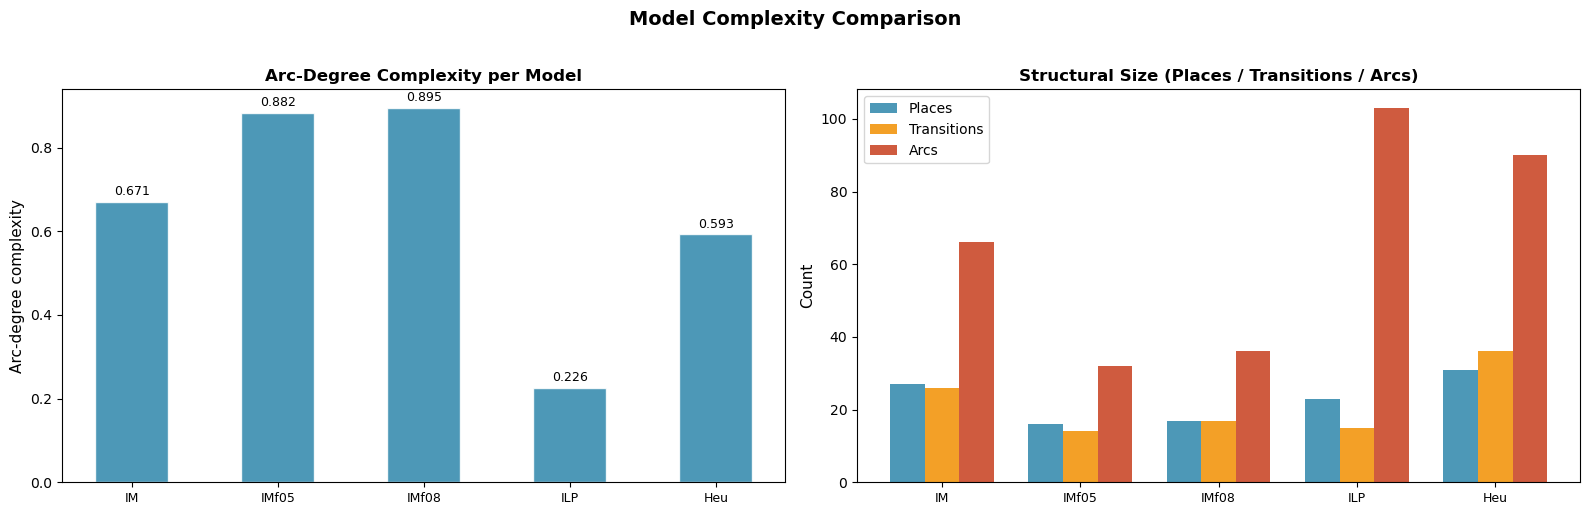

In [37]:
# Visual complexity comparison chart  
model_names = [m[0] for m in models]
arc_vals = [simp_results[m[0]]['arc_degree'] for m in models]
places_c = [len(m[1].places) for m in models]
trans_c = [len(m[1].transitions) for m in models]
arcs_c = [len(m[1].arcs) for m in models]

x = np.arange(len(models))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: arc degree per model 
ax = axes[0]
bars = ax.bar(x, arc_vals, color='#2E86AB', alpha=0.85, edgecolor='white', width=0.5)
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=0, fontsize=9)
ax.set_ylabel('Arc-degree complexity', fontsize=11)
ax.set_title('Arc-Degree Complexity per Model', fontsize=12, fontweight='bold')
for bar, val in zip(bars, arc_vals):
    if not np.isnan(val):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(arc_vals)*0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

# Right: structural counts (places / transitions / arcs)
ax2 = axes[1]
ax2.bar(x - width, places_c, width, label='Places', color='#2E86AB', alpha=0.85)
ax2.bar(x, trans_c, width, label='Transitions', color='#F18F01', alpha=0.85)
ax2.bar(x + width, arcs_c, width, label='Arcs', color='#C73E1D', alpha=0.85)
ax2.set_xticks(x)
ax2.set_xticklabels(model_names, rotation=0, fontsize=9)
ax2.set_ylabel('Count', fontsize=11)
ax2.set_title('Structural Size (Places / Transitions / Arcs)', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)

plt.suptitle('Model Complexity Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('images/simplicity_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [38]:
# Add simplicity metrics to the summary table
for i, (key, net, im, fm, title) in enumerate(models):
    summary_df.loc[title, 'Arc-degree'] = simp_results[key]['arc_degree']
    summary_df.loc[title, 'Cardoso'] = simp_results[key]['extended_cardoso']
    summary_df.loc[title, 'Cyclomatic'] = simp_results[key]['extended_cyclomatic']
    
print('FINAL SUMMARY TABLE (with complexity metrics)')
summary_df

FINAL SUMMARY TABLE (with complexity metrics)


,Sound,Log Fitness,Avg Trace Fitness,% Fitting Traces,Precision,Places,Transitions,Arcs,Arc-degree,Cardoso,Cyclomatic
Model,,,,,,,,,,,
Inductive Miner (noise=0.0),✓,1.0000,1.0000,100.0%,0.383257,27,26,66,0.670886,29.0,2819.0
IM infrequent (noise=0.5),✓,0.9368,0.9362,42.4%,0.956255,16,14,32,0.882353,16.0,20.0
IM infrequent (noise=0.8),✓,0.8871,0.8862,15.0%,0.969763,17,17,36,0.894737,17.0,19.0
ILP Miner,✗,0.7675,0.7672,0.0%,0.885128,23,15,103,0.226190,52.0,NaN
Heuristics Miner,✗,NaN,NaN,NaN,NaN,31,36,90,0.592920,44.0,12.0


The discovered models show the typical trade-off between fitness, precision, simplicity, and soundness.

The standard Inductive Miner produced a fully sound model with almost perfect fitness, meaning it can replay nearly all traces in the log. However, its low precision and very high complexity indicate overgeneralization and a large, complex model.

The Inductive Miner infrequent variants (noise = 0.5 and 0.8) generated much simpler and more precise models. Increasing the noise threshold improved precision, but reduced fitness and the percentage of perfectly fitting traces, since more infrequent behavior was filtered out.

The ILP Miner achieved relatively high fitness and precision, but the model was not sound. Therefore, these alignment-based metrics are not fully reliable, because unsound nets may contain deadlocks or invalid behavior that affects replay results.

The Heuristics Miner also produced a non-sound model, and alignment-based fitness and precision could not be computed at all. This highlights that soundness is a prerequisite for reliable conformance checking.

### <b>4d.</b> Identifying Imprecisions in the IMf Models
For the Inductive Miner infrequent (IMf) models, identify one behavior (sequence of
activities) allowed by the model that does not make sense and has no actual support
in the data. In other words, point out an imprecision of the model.

#### Custom functions for easier imprecisions search

In [39]:
# Extract activity label from a reachability-graph transition name 
def extract_label(ts_name):
    """
    Parse the activity label from a reachability-graph transition name string.
    Returns the label string for visible transitions, or None for silent ones.
    """
    m = re.search(r",\s*'(.+)'\)", ts_name)
    if m:
        return m.group(1)   # visible transition label
    return None             # silent transition (None in string = tau)

In [40]:
# Enumerate all complete model traces using BFS 
def get_all_model_traces(net, im, fm, max_depth=30, max_traces=2000):
    """
    Enumerate all distinct complete traces allowed by the Petri net
    via BFS over its reachability graph.
    """
    # Build reachability graph
    ts = pm4py.convert_to_reachability_graph(net, im, fm)

    # Build adjacency list: state_name -> [(label_or_None, next_state_name)]
    adj = {}
    for t in ts.transitions:
        label = extract_label(t.name)
        adj.setdefault(t.from_state.name, []).append((label, t.to_state.name))

    # Run BFS to find complete traces from 'source1' to 'sink1'
    # Track visited (state, trace) pairs to avoid looping.
    traces = set()
    queue = deque([('source1', ())])
    visited = set()

    while queue and len(traces) < max_traces:
        sn, trace = queue.popleft()

        key = (sn, trace)
        if key in visited:
            continue
        visited.add(key)

        # Reached the sink = complete trace
        if sn == 'sink1':
            traces.add(trace)
            continue

        # Stop if trace is already too long (catches unbounded loops)
        if len(trace) >= max_depth:
            continue

        for (label, next_sn) in adj.get(sn, []):
            if label is not None:          # visible transition: extend trace
                queue.append((next_sn, trace + (label,)))
            else:                          # silent transition: same trace
                queue.append((next_sn, trace))

    return traces

In [41]:
# Find the most similar log variant (shortest edit distance)
def edit_dist(a, b):
    # Simple Levenshtein distance on tuples
    m, n = len(a), len(b)
    dp = [[0]*(n+1) for _ in range(m+1)]
    for i in range(m+1): dp[i][0] = i
    for j in range(n+1): dp[0][j] = j
    for i in range(1, m+1):
        for j in range(1, n+1):
            dp[i][j] = dp[i-1][j-1] if a[i-1]==b[j-1] else 1+min(dp[i-1][j],dp[i][j-1],dp[i-1][j-1])
    return dp[m][n]

#### Back to the main question

In [42]:
# Collect log variants for comparison 
log_variants = set(pm4py.get_variants(rejected_loans).keys())

# Enumerate model-allowed traces for both IMf models 
imf_models = [(k, n, i, f, t) for k, n, i, f, t in models if 'infrequent' in t]

model_traces_dict = {}
for key, net, im, fm, title in imf_models:
    
    traces = get_all_model_traces(net, im, fm, max_depth=30, max_traces=2000)
    model_traces_dict[key] = traces
    imprecisions = traces - log_variants

    print(title)
    print(f'  Model traces : {len(traces)}')
    print(f'  Log variants : {len(log_variants)}')
    print(f'  Imprecisions : {len(imprecisions)} traces allowed by model but NOT in log', end='\n\n')

IM infrequent (noise=0.5)
  Model traces : 108
  Log variants : 61
  Imprecisions : 104 traces allowed by model but NOT in log

IM infrequent (noise=0.8)
  Model traces : 70
  Log variants : 61
  Imprecisions : 67 traces allowed by model but NOT in log



In [43]:
# Display the imprecise traces in detail 
for key, net, im, fm, title in imf_models:
    traces = model_traces_dict.get(key)

    imprecisions = traces - log_variants    # model allows but log does NOT have
    print(f'{"=" * 70}')
    print(f'{title}  |  Imprecisions : {len(imprecisions)}')
    print(f'{"=" * 70}')

    # We output few examples per category to keep the notebook readable
    shown = 0
    for tr in list(imprecisions)[:8]:   
        print(f'    {" -> ".join(tr)}')
        shown += 1
    if len(imprecisions) > shown:
        print(f'    ... ({len(imprecisions) - shown} more)')

IM infrequent (noise=0.5)  |  Imprecisions : 104
    Application Registered -> Retrieve Identity Document -> Verify ID Automatically -> Retrieve Internal Log Data -> Confirmed Identity -> Query Central Bank System -> Retrieve Customer Global Risk Score -> Query Credit Bureau -> Retrieve Financial Status -> Create Assessment Report -> Decide Loan Application -> Reject Application -> Reject Application -> Reject Application -> Reject Application -> Reject Application -> Reject Application -> Reject Application -> Reject Application -> Reject Application -> Reject Application -> Reject Application -> Reject Application -> Reject Application -> Send Rejection Notification
    Application Registered -> Retrieve Identity Document -> Verify ID Automatically -> Confirmed Identity -> Retrieve Internal Log Data -> Query Central Bank System -> Query Credit Bureau -> Retrieve Customer Global Risk Score -> Retrieve Financial Status -> Create Assessment Report -> Decide Loan Application -> Reject Ap

In [44]:
# Highlight one imprecision of IMf-0.5 
imf05_traces = model_traces_dict.get('IMf05')
imf05_imprecisions = sorted(imf05_traces - log_variants, key=len)

if imf05_imprecisions:
    example = imf05_imprecisions[-1] 
    print('HIGHLIGHTED IMPRECISION IN IMf-0.5')
    print('=' * 100)

    closest = min(log_variants, key=lambda v: edit_dist(example, v))
    dist    = edit_dist(example, closest)
    
    for i, act in enumerate(example, 1):
        print(f'    Step {i:<2}: {act:<35}', end='')
        if i <= len(closest):
            print(f'      Closest log step: {closest[i-1]}')
        else:
            print()

    print(f'The closest log variant is at an edit distance of {dist}.')

else:
    print('No imprecisions found in IMf-0.5 (all model traces are in the log).')

HIGHLIGHTED IMPRECISION IN IMf-0.5
    Step 1 : Application Registered                   Closest log step: Application Registered
    Step 2 : Retrieve Identity Document               Closest log step: Retrieve Identity Document
    Step 3 : Retrieve Internal Log Data               Closest log step: Retrieve Internal Log Data
    Step 4 : Verify ID Automatically                  Closest log step: Verify ID Automatically
    Step 5 : Confirmed Identity                       Closest log step: Confirmed Identity
    Step 6 : Query Central Bank System                Closest log step: Query Central Bank System
    Step 7 : Query Credit Bureau                      Closest log step: Query Credit Bureau
    Step 8 : Retrieve Customer Global Risk Score      Closest log step: Retrieve Customer Global Risk Score
    Step 9 : Retrieve Financial Status                Closest log step: Retrieve Financial Status
    Step 10: Create Assessment Report                 Closest log step: Create Assessment

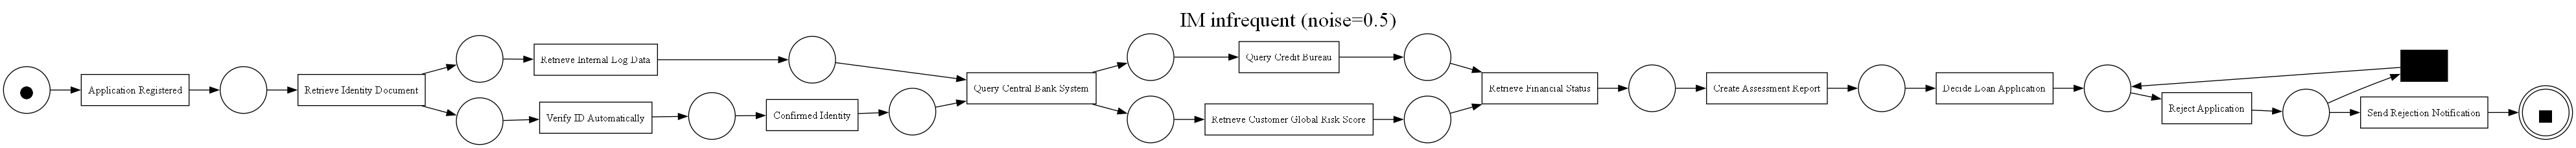

In [45]:
# Take a look again at the IMf-0.5 model
display(Image(filename='images/model_IMf05.png'))

The IMf-0.5 model trace highlighted above shows a critical flaw: an unbounded loop on `Reject Application`. When aligning this model trace against the closest matching log variant, the comparison shows that after `Decide Loan Application` fires at step 12, the model continues repeating `Reject Application` for 18 consecutive repetitions, before finally reaching `Send Rejection Notification`.

It is important to remember that a hard limit was set during model trace findings to prevent infinite expansion. Without that cap, the loop would continue indefinitely. This means the IMf-0.5 model technically permits an infinite number of rejections, which clearly does not make sense from a real-world perspective.

### <b>4e.</b> Final Model Comparison
Rank the models based on the results obtained in the above subquestions. For
each model, give your overall impression, and state whether you think it is a useful
model or not. Give at least two reasons for your decision. 

1. **Inductive Miner infrequent (noise = 0.5)**
   This is the best overall compromise between simplicity, precision, and soundness. The model is much smaller and more precise than the standard IM while still remaining sound, although it allows the unrealistic infinite repetition of `Reject Application`, which reduces its practical realism. 

2. **Inductive Miner infrequent (noise = 0.8)**
   This model is the simplest and most precise sound model, making it easy to interpret and less overgeneralized. However, its lower fitness means that much observed behavior is excluded, and it also suffers from the same infinite rejection loop issue.

3. **Inductive Miner – standard (noise = 0.0)**
   The standard IM achieves almost perfect fitness and is sound, but it is extremely complex and heavily overgeneralizes behavior. In addition, it also contains the unrealistic infinite `Reject Application` loop.

4. **ILP Miner**
   The ILP Miner provides relatively strong fitness and precision values, but the model is not sound, making these metrics less trustworthy. Its high complexity and structural issues reduce its usefulness as a reliable process model.

5. **Heuristics Miner**
   This is the weakest model because it is not sound and alignment-based fitness and precision could not be computed. Since the model cannot guarantee correct execution behavior, it is not suitable for dependable conformance analysis.


## <b>Question 5</b>: Conformance Checking

### <b>5a.</b> Load and visualize the two Petri nets
Load and visualize the following Petri nets.
- pn_loan_inductive.pnml
- pn_loan_handmade.pnml

Briefly describe how these models differ. (approx. 3-4 sentences)


In [46]:
# Load both Petri nets
pn_ind,  im_ind,  fm_ind = pm4py.read_pnml("Input Process Models/pn-loan-inductive.pnml")
pn_hand, im_hand, fm_hand = pm4py.read_pnml("Input Process Models/pn-loan-handmade.pnml")

def describe(name, pn):
    visible = [t for t in pn.transitions if t.label is not None]
    silent = [t for t in pn.transitions if t.label is None]
    from collections import Counter
    dup = {l:c for l,c in Counter(t.label for t in visible).items() if c > 1}
    print(f"{name:25s}  places={len(pn.places):3d}  transitions={len(pn.transitions):3d}"
          f"  (visible={len(visible)}, silent={len(silent)})  arcs={len(pn.arcs):3d}")
    if dup:
        print(f"   duplicate labels: {dup}")

describe("pn_loan_inductive", pn_ind)
describe("pn_loan_handmade",  pn_hand)

pn_loan_inductive          places= 36  transitions= 39  (visible=26, silent=13)  arcs= 90
pn_loan_handmade           places= 27  transitions= 32  (visible=29, silent=3)  arcs= 69
   duplicate labels: {'Reject Application': 3, 'Confirmed Identity': 2}


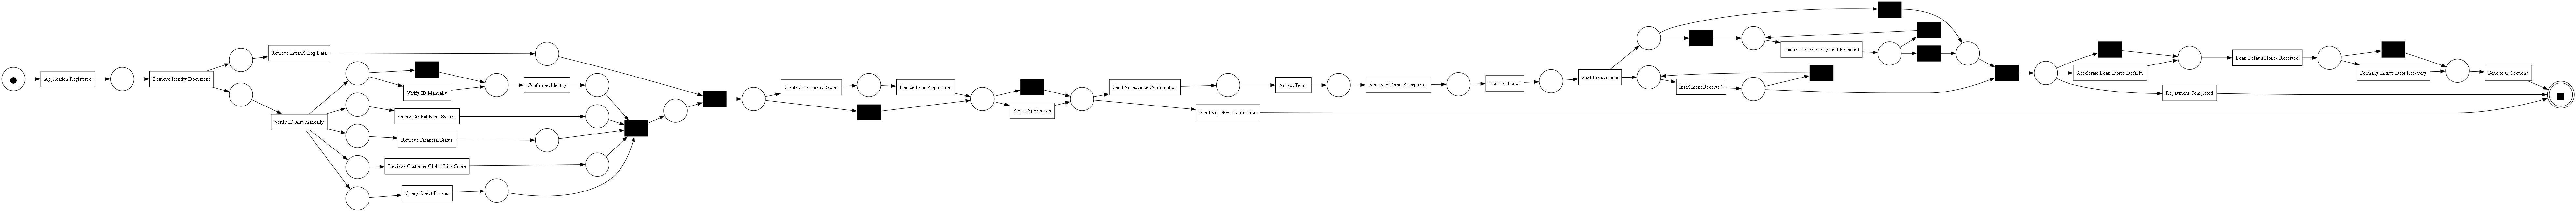

In [47]:
# Visualize the inductive Petri net (rendered inline) and save to directory
pm4py.save_vis_petri_net(pn_ind, im_ind, fm_ind, "images/pn_inductive.png")
Image("images/pn_inductive.png")

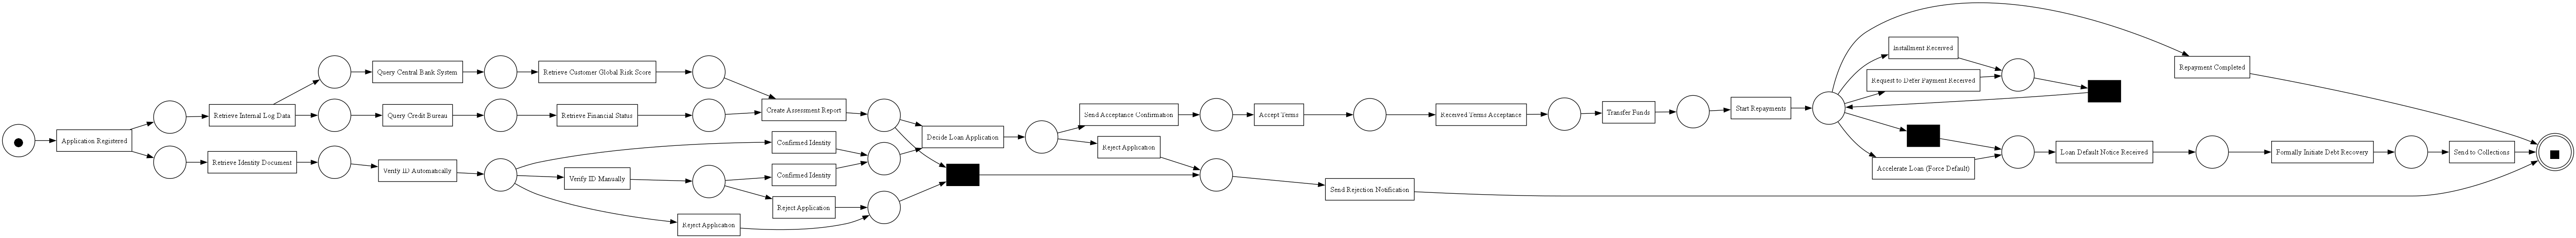

In [48]:
# Visualize the handmade Petri net (rendered inline) and save to directory
pm4py.save_vis_petri_net(pn_hand, im_hand, fm_hand, "images/pn_handmade.png")
Image("images/pn_handmade.png")

Both nets use the same 26 activity labels but look very different. The inductive model has 36 places and 39 transitions (26 visible + 13 silent), and every label only appears once — the silent transitions are used to model skips and loops, which is typical for the Inductive Miner. The handmade model is smaller (27 places, 32 transitions, only 3 silent), but it uses duplicate labels: `Reject Application` appears **3 times** (once for each rejection point in the process) and `Confirmed Identity` appears **2 times** (once after the automatic and once after the manual ID check). So the handmade model shows the different cases directly with duplicate transitions, while the inductive model uses silent transitions and routing places instead.

### <b>5b.</b> Token-based fitness, alignment-based fitness and alignment-based precision on all.xes
For both models, calculate and report token-based and alignment-based fitness as well as
alignment-based precision on the event log all.xes.


In [49]:
def evaluate(name, pn, im, fm):
    tb_fit = pm4py.fitness_token_based_replay(all_log, pn, im, fm)
    al_fit = pm4py.fitness_alignments(all_log, pn, im, fm)
    al_prec = pm4py.precision_alignments(all_log, pn, im, fm)
    print(f"\n=== {name} ===")
    print(f"  token-based fitness     : log_fitness  = {tb_fit['log_fitness']:.4f},"
          f"  perc_fit_traces = {tb_fit['perc_fit_traces']:.2f}%")
    print(f"  alignment-based fitness : log_fitness  = {al_fit['log_fitness']:.4f},"
          f"  perc_fit_traces = {al_fit['percentage_of_fitting_traces']:.2f}%")
    print(f"  alignment-based precision: {al_prec:.4f}")
    return {"tb": tb_fit['log_fitness'], "al": al_fit['log_fitness'],
            "fit_traces": al_fit['percentage_of_fitting_traces'], "prec": al_prec}

scores_ind = evaluate("pn_loan_inductive", pn_ind,  im_ind,  fm_ind)
scores_hand = evaluate("pn_loan_handmade",  pn_hand, im_hand, fm_hand)

replaying log with TBR, completed traces ::   0%|          | 0/678 [00:00<?, ?it/s]

aligning log, completed variants ::   0%|          | 0/678 [00:00<?, ?it/s]

computing precision with alignments, completed variants ::   0%|          | 0/4984 [00:00<?, ?it/s]


=== pn_loan_inductive ===
  token-based fitness     : log_fitness  = 0.9967,  perc_fit_traces = 95.22%
  alignment-based fitness : log_fitness  = 0.9974,  perc_fit_traces = 95.22%
  alignment-based precision: 0.7311


replaying log with TBR, completed traces ::   0%|          | 0/678 [00:00<?, ?it/s]

aligning log, completed variants ::   0%|          | 0/678 [00:00<?, ?it/s]

computing precision with alignments, completed variants ::   0%|          | 0/4984 [00:00<?, ?it/s]


=== pn_loan_handmade ===
  token-based fitness     : log_fitness  = 0.9974,  perc_fit_traces = 94.29%
  alignment-based fitness : log_fitness  = 0.9971,  perc_fit_traces = 94.29%
  alignment-based precision: 0.5827


Both models replay `all.xes` very well in terms of fitness, but differ in precision.

| Metric | `pn_loan_inductive` | `pn_loan_handmade` |
|---|---|---|
| Token-based fitness (`log_fitness`) | **0.9967** | **0.9974** |
| Alignment-based fitness (`log_fitness`) | **0.9974** | **0.9971** |
| % perfectly fitting traces | **95.22 %** | **94.29 %** |
| Alignment-based precision | **0.7311** | **0.5827** |

### <b>5c.</b> Soundness of pn_loan_handmade
For pn_loan_handmade, explain for each property of soundness, whether it holds or not.


In [50]:
# Run the soundness check on the handmade net
sound_ok, diag = pm4py.check_soundness(pn_hand, im_hand, fm_hand)
print(f"is_sound = {sound_ok}")
print("Diagnostic messages:")
from pm4py.algo.analysis.woflan.algorithm import Outputs
for m in diag[Outputs.DIAGNOSTIC_MESSAGES]:
    print(" -", m)

is_sound = True
Diagnostic messages:
 - Input is ok.
 - Petri Net is a workflow net.
 - Every place is covered by s-components.
 - There are no dead tasks.
 - All tasks are live.


`pm4py.check_soundness` returns `True` for `pn_loan_handmade`, so all four properties of (Workflow-net) soundness hold. The diagnostic messages from the soundness check confirm this:

| Property | Holds? | Why? |
|---|---|---|
| **Workflow-net structure** (one start place, one end place, every node lies on a path from start to end) | ✓ | The check tells us *"Petri Net is a workflow net."* |
| **Option to complete** (from every reachable marking we can still reach the final marking `[n25]`) | ✓ | The check tells us *"Every place is covered by s-components."* This means no token can get stuck somewhere, so we can always still reach the final marking. |
| **Proper completion** (when we reach the final marking, no other tokens are left somewhere else) | ✓ | The workflow-net structure together with the s-component coverage make sure that the final marking `[n25]` is the only end state and that it has exactly one token in it. |
| **No dead transitions** (every transition can fire in at least one run) | ✓ | The check tells us *"There are no dead tasks."* and *"All tasks are live."* |

### <b>5d.</b> Which model better represents the actual process?
Choose which of the two models you would claim represents the actual process the best.
Justify your recommendation by referencing the scores, model complexity, and permitted
behavior, and also considering your understanding of the process.


Both models have very similar fitness (around 0.997), but the `pn_loan_inductive` model fits the *actual* process in `all.xes` better. There are three reasons for this:

- **Scores.** The inductive model has a higher precision (0.7311 vs. 0.5827) and more perfectly fitting traces (95.22 % vs. 94.29 %), and the fitness is basically the same. A higher precision means the model allows less behavior that we did *not* see in the log, which is what we want when we describe the actual process.
- **Allowed behavior.** The lower precision of the handmade model comes from how it handles rejections: it has three `Reject Application` transitions next to each other, which means it allows manual rejections that skip the assessment report, and also lets you mix the auto-reject and the manual-reject path in ways that never happen in the data. On the other side, the handmade model does *not* allow some things that we *did* see in Q3, like the auto-rejection of LCS cases without `Decide Loan Application`. We will look at this more closely in (e)–(h).
- **Complexity.** The handmade model has a few less places and transitions than the inductive one (27/32 vs. 36/39), but it has 3 duplicate labels, which makes it harder to read in a complex net than the inductive model where every label only appears once. Together with (a) and (c), this makes the inductive model the better choice for *describing* the actual process. The handmade model is still useful as the *normative* model, which is what we use it for in (e)–(i).

### <b>5e.</b> Alignments on accepted-loans.xes
Load the accepted-loans.xes event log that contains all the loan applications that were
accepted. Calculate alignments. Which activities appear problematic in the model?


For (e)–(i) the process owner says that `pn_loan_handmade` should be seen as the *normative* model — the model that describes how the process *should* run. We now check how three sub-logs fit this model and look at where they deviate:

- **(e)** `accepted-loans.xes` — cases where the loan was accepted and the money was transferred
- **(g)** `lcs-rejected-customers.xes` — cases of customers that were rejected with the LCS code at some point
- **(h)** `mid-rejected-customers.xes` — cases of customers that were rejected with the MID code at some point

We write a small helper function for this, use it in (e), and then call it again in (g) and (h) on the other two sub-logs.

In [51]:
def conformance_report(log_path, label, n_examples=2):
    sub_log = pm4py.read_xes(log_path)
    n_cases = sub_log["case:concept:name"].nunique()
    fit = pm4py.fitness_alignments(sub_log, pn_hand, im_hand, fm_hand)
    aligns = pm4py.conformance_diagnostics_alignments(sub_log, pn_hand, im_hand, fm_hand)

    log_moves = Counter()
    model_moves = Counter()
    bad_cases = []

    case_ids = sub_log["case:concept:name"].unique()
    for cid, al in zip(case_ids, aligns):
        is_deviating = False
        for log_lbl, model_lbl in al["alignment"]:
            # visible model move
            if log_lbl == ">>" and model_lbl is not None:
                model_moves[model_lbl] += 1
                is_deviating = True
            # log move
            elif model_lbl == ">>":
                log_moves[log_lbl] += 1
                is_deviating = True
        if is_deviating:
            bad_cases.append((cid, al))

    print(f"\n--- {label} ---")
    print(f"# cases: {n_cases}")
    print(f"alignment log fitness: {fit['log_fitness']:.4f}")
    print(f"% perfectly fitting traces: {fit['percentage_of_fitting_traces']:.2f}%")
    print(f"# non-fitting traces: {len(bad_cases)}")

    print("\nTop activities expected by model but missing in log:")
    for a, c in model_moves.most_common(5):
        print(f"  {a}: {c}")

    print("\nTop activities in log but not allowed by model here:")
    for a, c in log_moves.most_common(5):
        print(f"  {a}: {c}")

    # show a few example alignments
    if bad_cases:
        print("\nExample alignments of non-fitting cases:")
        for cid, al in bad_cases[:n_examples]:
            print(f"\ncase {cid} (fitness {al['fitness']:.3f}):")
            for log_lbl, model_lbl in al["alignment"]:
                # skip silent model moves to keep the output readable
                if log_lbl == ">>" and model_lbl is None:
                    continue
                if log_lbl != ">>" and model_lbl != ">>":
                    marker = "ok"
                elif log_lbl == ">>":
                    marker = "M>"
                else:
                    marker = "L>"
                print(f"  {marker}  log={log_lbl}  model={model_lbl}")

    return {"fit": fit, "log_moves": log_moves, "model_moves": model_moves}


res_acc = conformance_report("Event Logs/accepted-loans.xes",
                             "(e) ACCEPTED-LOANS vs pn_loan_handmade")

parsing log, completed traces ::   0%|          | 0/1499 [00:00<?, ?it/s]

aligning log, completed variants ::   0%|          | 0/617 [00:00<?, ?it/s]

aligning log, completed variants ::   0%|          | 0/617 [00:00<?, ?it/s]


--- (e) ACCEPTED-LOANS vs pn_loan_handmade ---
# cases: 1499
alignment log fitness: 0.9995
% perfectly fitting traces: 98.60%
# non-fitting traces: 21

Top activities expected by model but missing in log:
  Formally Initiate Debt Recovery: 13
  Retrieve Internal Log Data: 5
  Query Credit Bureau: 3

Top activities in log but not allowed by model here:
  Retrieve Internal Log Data: 5
  Query Credit Bureau: 3

Example alignments of non-fitting cases:

case 635-446 (fitness 0.950):
  ok  log=Application Registered  model=Application Registered
  ok  log=Retrieve Identity Document  model=Retrieve Identity Document
  L>  log=Query Credit Bureau  model=>>
  ok  log=Retrieve Internal Log Data  model=Retrieve Internal Log Data
  M>  log=>>  model=Query Credit Bureau
  ok  log=Retrieve Financial Status  model=Retrieve Financial Status
  ok  log=Verify ID Automatically  model=Verify ID Automatically
  ok  log=Confirmed Identity  model=Confirmed Identity
  ok  log=Query Central Bank System  mode

Almost all accepted loans fit the normative model: alignment log-fitness is **0.9995** and **98.60 %** of the traces fit perfectly. Out of the 21 cases that don't fit, the main problem is `Formally Initiate Debt Recovery` — the model expects this activity, but the log does not have it (most of the model moves are on this activity). A few cases also have small ordering issues with `Retrieve Internal Log Data`, `Query Credit Bureau` and `Query Central Bank System`.

### <b>5f.</b> Inspect alignments on accepted-loans.xes
Manually inspect a few alignments. Describe 2 reasons for conformance issues.


The two example alignments above show two different reasons for conformance issues:

1. **Formal debt recovery is sometimes skipped on default cases.** When an accepted loan ends up in default, the normative model says it should go `Loan Default Notice Received → Formally Initiate Debt Recovery → Send to Collections`. But in some cases the log goes directly from `Loan Default Notice Received` to `Send to Collections`, so `Formally Initiate Debt Recovery` is missing. This means the collections process is started without the formal debt recovery being recorded.
2. **Information-gathering activities sometimes happen in a different order.** `Retrieve Internal Log Data`, `Query Credit Bureau`, `Query Central Bank System` and `Retrieve Financial Status` can run in parallel (we already saw this in Q2(a) and Q2(b)), but the model has a stricter order than what we see in the log. For example, in one of the cases above `Query Credit Bureau` comes before `Retrieve Internal Log Data`, which gives one log move and one model move for the same activity. This is more of a modelling problem than a real process violation.

### <b>5g.</b> Conformance on lcs-rejected-customers.xes
Load the lcs-rejected-customers.xes event log. Repeat the steps from e and f.


In [52]:
res_lcs = conformance_report("Event Logs/lcs-rejected-customers.xes",
                              "(g) LCS-REJECTED  vs  pn_loan_handmade")

parsing log, completed traces ::   0%|          | 0/139 [00:00<?, ?it/s]

aligning log, completed variants ::   0%|          | 0/58 [00:00<?, ?it/s]

aligning log, completed variants ::   0%|          | 0/58 [00:00<?, ?it/s]


--- (g) LCS-REJECTED  vs  pn_loan_handmade ---
# cases: 139
alignment log fitness: 0.9533
% perfectly fitting traces: 41.01%
# non-fitting traces: 82

Top activities expected by model but missing in log:
  Create Assessment Report: 81
  Decide Loan Application: 79
  Retrieve Internal Log Data: 1

Top activities in log but not allowed by model here:
  Reject Application: 2
  Retrieve Internal Log Data: 1

Example alignments of non-fitting cases:

case 756-74 (fitness 0.913):
  ok  log=Application Registered  model=Application Registered
  ok  log=Retrieve Identity Document  model=Retrieve Identity Document
  ok  log=Verify ID Automatically  model=Verify ID Automatically
  ok  log=Retrieve Internal Log Data  model=Retrieve Internal Log Data
  ok  log=Query Central Bank System  model=Query Central Bank System
  ok  log=Retrieve Customer Global Risk Score  model=Retrieve Customer Global Risk Score
  ok  log=Verify ID Manually  model=Verify ID Manually
  ok  log=Confirmed Identity  model=C

The LCS sub-log fits much worse than the accepted loans: alignment fitness drops to **0.9533** and only **41.0 %** of the 139 traces fit perfectly. The biggest deviation is structural: in 81 and 79 cases respectively, `Create Assessment Report` and `Decide Loan Application` are expected by the model but never happen in the log. Looking at the example alignments, this happens whenever a customer is auto-rejected because their risk score is too high: the log goes directly from `Retrieve Financial Status` to `Reject Application` to `Send Rejection Notification`, without doing the assessment report or the manual decision in between. The normative model does *not* allow this short-cut — every rejection path in `pn_loan_handmade` goes through `Decide Loan Application`. This is the same thing we already noticed in Q3(c).

Reasons for the conformance issues:

1. **Auto-rejection skips the manual decision.** The system automatically rejects customers with a very high risk score, but the normative model does not include this path. This is why we see model moves on `Create Assessment Report` and `Decide Loan Application` in so many cases.
2. **`Reject Application` happens at an unexpected position.** A small number of cases (2) trigger `Reject Application` at a point where the normative model does not allow it, which gives a log move. These are probably cases where a previous application of the same customer was already rejected, and the rejection event ended up in the next case. The LCS sub-log contains *all* cases of customers that were ever rejected with LCS, so the same customer can appear with multiple loan attempts.

### <b>5h.</b> Conformance on mid-rejected-customers.xes
Load the mid-rejected-customers.xes event log that contains all applications that were
rejected with the MID reason code. Repeat the steps from e and f.


In [53]:
res_mid = conformance_report("Event Logs/mid-rejected-customers.xes",
                              "(h) MID-REJECTED  vs  pn_loan_handmade")

parsing log, completed traces ::   0%|          | 0/8 [00:00<?, ?it/s]

aligning log, completed variants ::   0%|          | 0/6 [00:00<?, ?it/s]

aligning log, completed variants ::   0%|          | 0/6 [00:00<?, ?it/s]


--- (h) MID-REJECTED  vs  pn_loan_handmade ---
# cases: 8
alignment log fitness: 0.9780
% perfectly fitting traces: 75.00%
# non-fitting traces: 2

Top activities expected by model but missing in log:
  Create Assessment Report: 2

Top activities in log but not allowed by model here:
  Reject Application: 2

Example alignments of non-fitting cases:

case 358-964 (fitness 0.909):
  ok  log=Application Registered  model=Application Registered
  ok  log=Retrieve Identity Document  model=Retrieve Identity Document
  ok  log=Retrieve Internal Log Data  model=Retrieve Internal Log Data
  ok  log=Verify ID Automatically  model=Verify ID Automatically
  ok  log=Reject Application  model=Reject Application
  ok  log=Query Central Bank System  model=Query Central Bank System
  ok  log=Query Credit Bureau  model=Query Credit Bureau
  ok  log=Retrieve Financial Status  model=Retrieve Financial Status
  ok  log=Retrieve Customer Global Risk Score  model=Retrieve Customer Global Risk Score
  M>  lo

The MID sub-log is small (8 cases) and fits the model quite well overall (alignment fitness **0.978**, **75 %** perfectly fitting), but the two non-fitting cases show an interesting pattern: each of them contains `Reject Application` *twice* — once as a sync move and once as a log move — and skips `Create Assessment Report`.

Reasons for the conformance issues:

1. **Two rejections in the same case.** First, the customer's documents are found to be missing or incorrect, so `Reject Application` happens directly after `Verify ID Automatically`. The case then continues with the normal information-gathering activities (probably because the customer sent in the documents again) and is rejected a *second* time at the end. The normative model only allows one `Reject Application` per case, so the second one shows up as a log move.
2. **No assessment when the application is clearly not okay.** When the application is rejected straight away because of a MID issue, `Create Assessment Report` is not done at all. The model expects it, which is why we see a model move on `Create Assessment Report`. This is the same kind of deviation as the LCS auto-rejections, just on a much smaller scale.

### <b>5i.</b> Summary of findings and recommendations
Summarize your findings. Based on the normative model, what recommendations would
you give for improving the process? (approx. 2-3 sentences)


The normative model fits the accepted-loans branch very well (≥98.6 % fitting traces), but it does not cover the early-rejection short-cuts that exist in reality — both LCS auto-rejections and MID rejections skip `Create Assessment Report` and `Decide Loan Application`, which the model requires. To fix this, the normative model should be updated so that the rejection branch can also be entered before `Create Assessment Report` and without `Decide Loan Application`, and `Formally Initiate Debt Recovery` should be enforced on every default-to-collections path. We would also recommend looking into the duplicate `Reject Application` events in the MID cases, since they probably point to a process gap where a re-submission re-uses the same case instead of opening a new one.